In [9]:
# to_save, to_load = False, True
session_file = "./tmp/TIC_430091448_EA.ipynb.pkl"

# # load/save the notebook session
# # https://dill.readthedocs.io/en/latest/
# if True: 
#     import dill
#     import sys
#     if "../" not in sys.path:  # to get my usual helpers at base dir
#         sys.path.append("../")
#     if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
#         sys.path.append("../eb_with_diff_sb_period/etv/")
#     dill.load_module(session_file)
#     print(f"Notebook session loaded from  {session_file}")

# if True:  # save the notebook session
#     import dill
#     dill.dump_module(session_file)
#     print(f"Notebook session saved in {session_file}")


Notebook session saved in ./tmp/TIC_430091448_EA.ipynb.pkl


In [1]:
import sys
if "../" not in sys.path:  # to get my usual helpers at base dir
    sys.path.append("../")

import lightkurve as lk
from lightkurve_ext import of_sector, of_sectors, of_2min_cadences
import lightkurve_ext as lke
from lightkurve_ext import TransitTimeSpec, TransitTimeSpecList
import lightkurve_ext_tess as lket
import lightkurve_ext_pg as lke_pg
import lightkurve_ext_pg_runner as lke_pg_runner
import tic_plot as tplt

import asyncio_compat

import math
import re
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplotlib

import pandas as pd
import astropy as astropy
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
from astropy.io import fits

from matplotlib.ticker import (FormatStrFormatter, AutoMinorLocator)

from importlib import reload # useful during development to reload packages

from IPython.display import display, HTML, Javascript, clear_output

display(HTML("<style>.container { width:99% !important; }</style>"))  # Jupyter 6
display(HTML("<style>.jp-Notebook { --jp-notebook-max-width: 98%; }</style>"))  # Jupyter 7


# No longer works in Jupyter 7+
display(Javascript("""
// export notebook url to Python for bokeh-based interactive features
if (window["IPython"] != null) {
  IPython.notebook.kernel.execute(`notebook_url = "${window.location.origin}"`);
} else {
  console.warn("IPython js object not available (in Jupyter 7). Hardcode notebook_url in the notebook itself instead.")
}
"""));
notebook_url = "localhost:8888"

%matplotlib inline

# data cache config
lk_download_dir = '../data'
if hasattr(lk, "conf"):  # default download dir
    lk.conf.cache_dir = lk_download_dir

# make markdown table aligned to the left of the cell output (instead of center)
display(HTML("<style>table {margin-left: 4ch;}</style>"))

<IPython.core.display.Javascript object>

# TIC  Analysis (EA)

- new VSX entry
- TESS data contaminated by the brighter TIC 430091451 8.6" away
- https://www.zooniverse.org/projects/sofia-dot-marie/classifying-the-classified-2025/talk/7167/3813268?comment=6299194&page=1

## TESS Data

In [4]:
tic = 430091448

sr = lk.search_lightcurve(f"TIC{tic}", )  # author="SPOC", cadence="short"
sr_unfiltered = sr  # keep a copy
sr = lke.filter_by_priority(sr, author_priority = ["QLP"])  # "SPOC", "TESS-SPOC", 
# sr = sr[sr.author == "QLP"]  # for uniformity, only 1 sector (3) has no QLP data
# sr = lke._sort_chronologically(sr)

astropy.table.pprint.conf.max_lines = 100  # to print all rows
display(sr)

# Note: only 1 sector of ready made lightcurve
# if needed, lightcurves can be created from sectors 37, 63, 64 (and in the future 90, 99, 100, 101)
lcc_tess = sr.download_all()
lcc_tess

#,mission,year,author,exptime,target_name,distance,proposal_id
,,,,s,,arcsec,
0,TESS Sector 43,2021,QLP,600,430091448,0.0,N/A
1,TESS Sector 44,2021,QLP,600,430091448,0.0,N/A
2,TESS Sector 45,2021,QLP,600,430091448,0.0,N/A
3,TESS Sector 71,2023,QLP,200,430091448,0.0,N/A
4,TESS Sector 72,2023,QLP,200,430091448,0.0,N/A


LightCurveCollection of 5 objects:
    0: <TessLightCurve LABEL="TIC 430091448" SECTOR=43 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    1: <TessLightCurve LABEL="TIC 430091448" SECTOR=44 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    2: <TessLightCurve LABEL="TIC 430091448" SECTOR=45 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    3: <TessLightCurve LABEL="TIC 430091448" SECTOR=71 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    4: <TessLightCurve LABEL="TIC 430091448" SECTOR=72 AUTHOR=QLP FLUX_ORIGIN=sap_flux>

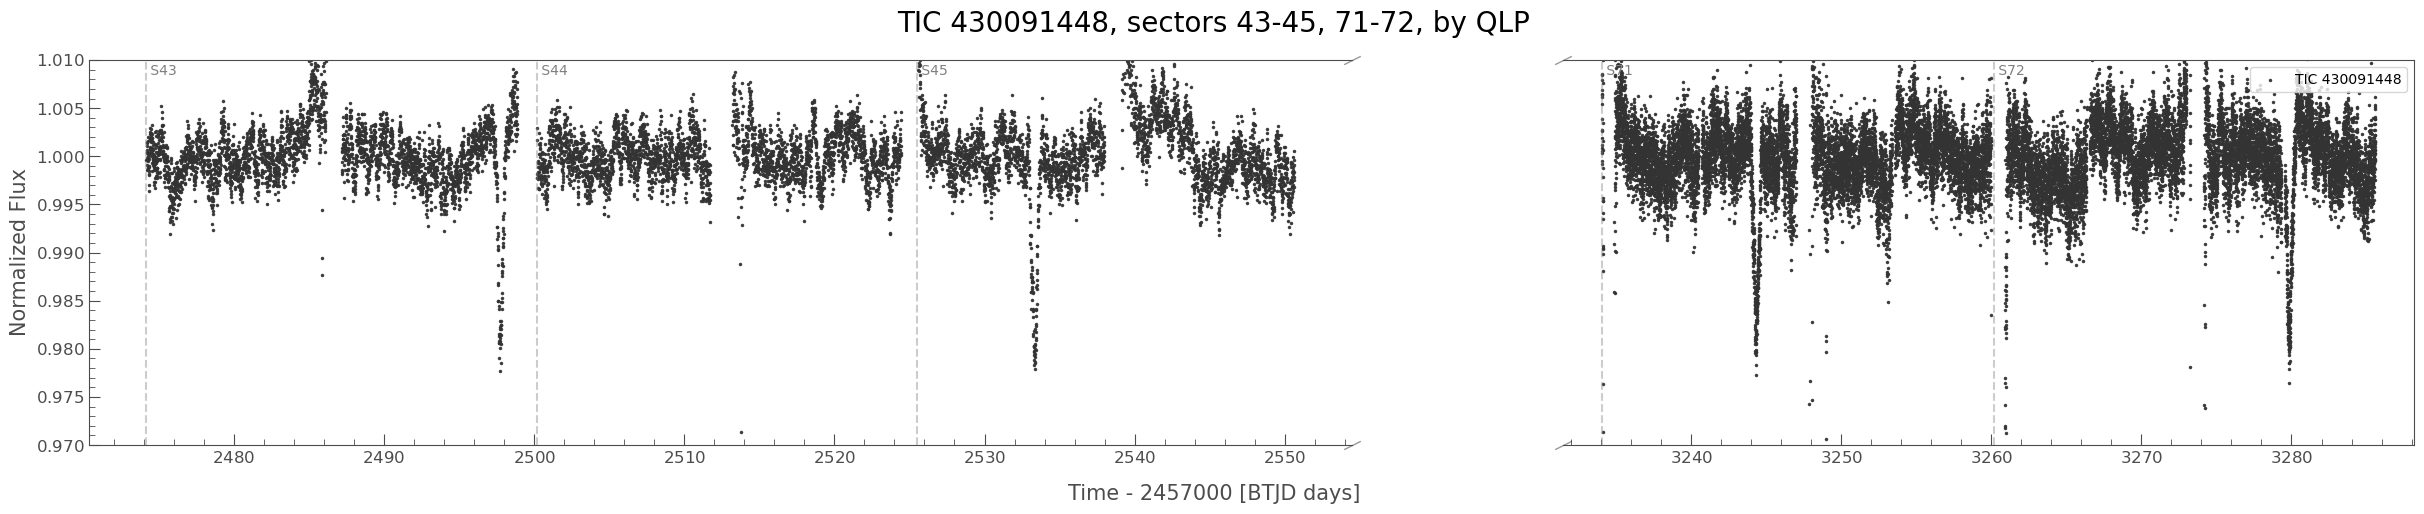

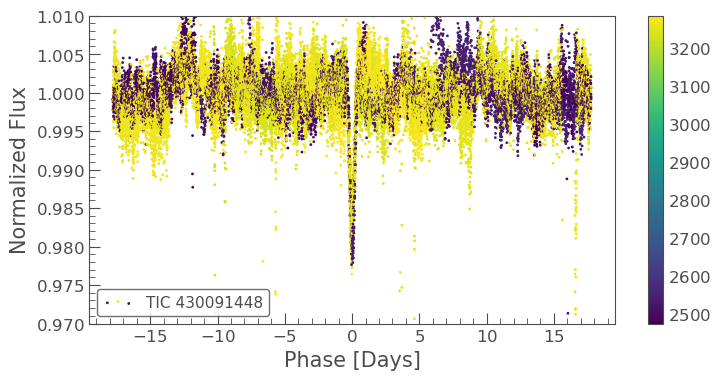

In [5]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True)  # , corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);
[ax.set_ylim(0.97, 1.01) for ax in axs];

_lc_f = _lc.fold(period=35.5524, epoch_time=Time(2497.73, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
ax.set_ylim(0.97, 1.01);
# ax.set_xlim(5, 10); ax.set_ylim(0.95, None);  # zoomed around Min II

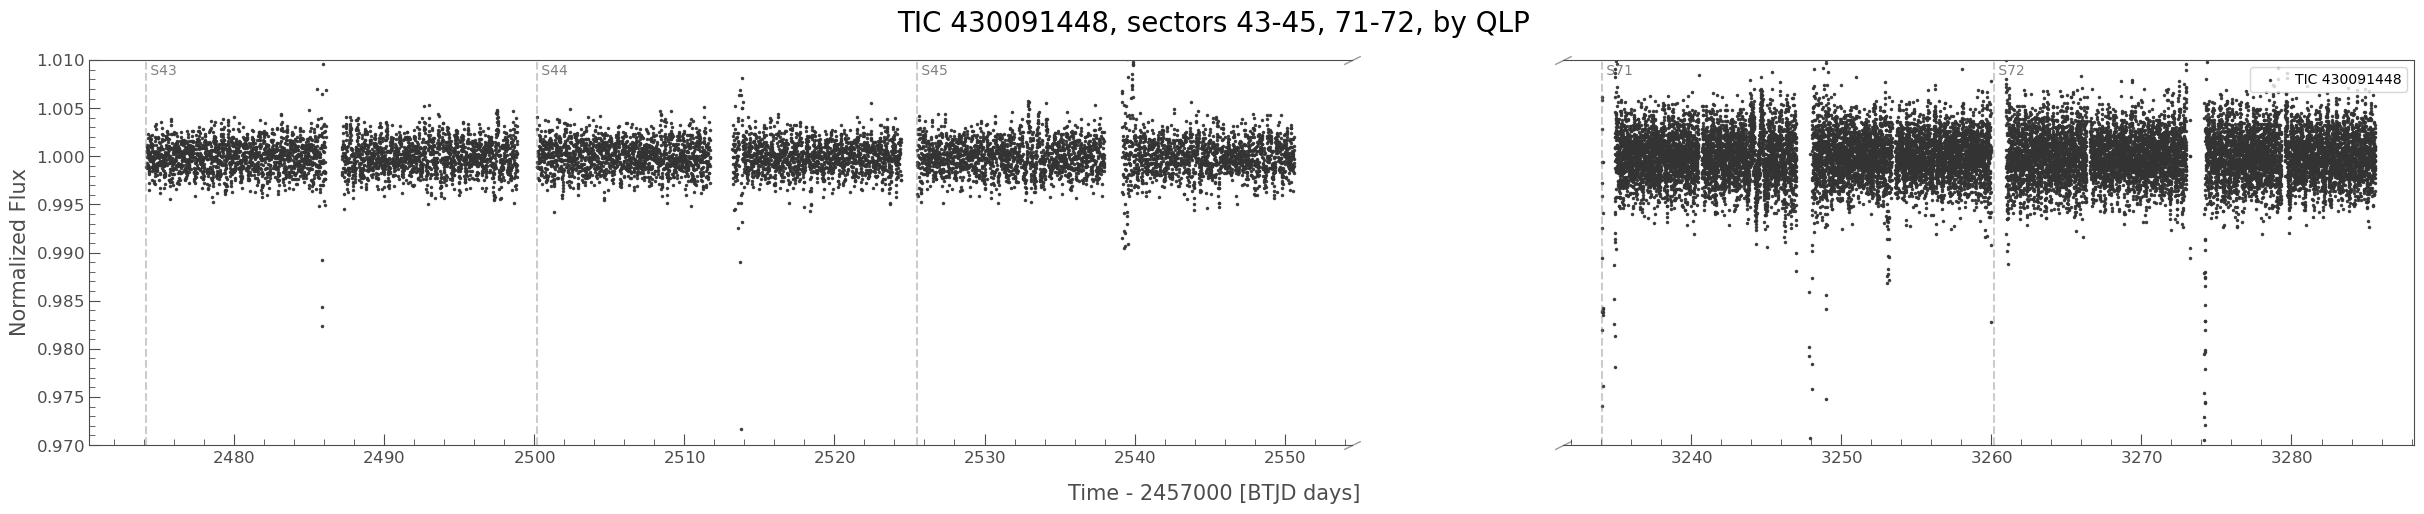

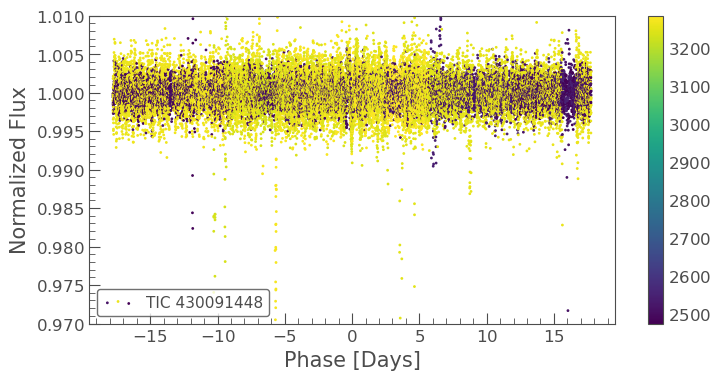

In [11]:
# No good: the detrend seems to have done away the eclipses as well
_lc = lke.stitch(lcc_tess, corrector_func=lambda lc: lke.select_flux(lc, ["det_flux", "kspsap_flux"]).normalize(), ignore_incompatible_column_warning=True)  # , corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);
[ax.set_ylim(0.97, 1.01) for ax in axs];

_lc_f = _lc.fold(period=35.5524, epoch_time=Time(2497.73, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
ax.set_ylim(0.97, 1.01);
# ax.set_xlim(5, 10); ax.set_ylim(0.95, None);  # zoomed around Min II

In [ ]:
# truncating the eclipses to see out of eclipse variation

# _ylim = (0.97, 1.01)
# axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
# axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author} ", fontsize=20);
# [ax.set_ylim(*_ylim) for ax in axs];

# ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
# ax.set_ylim(*_ylim);

### Contamination (in TESS Pixels)

- target (red arrow) and the nearby brighter contaminat (black crosshair)

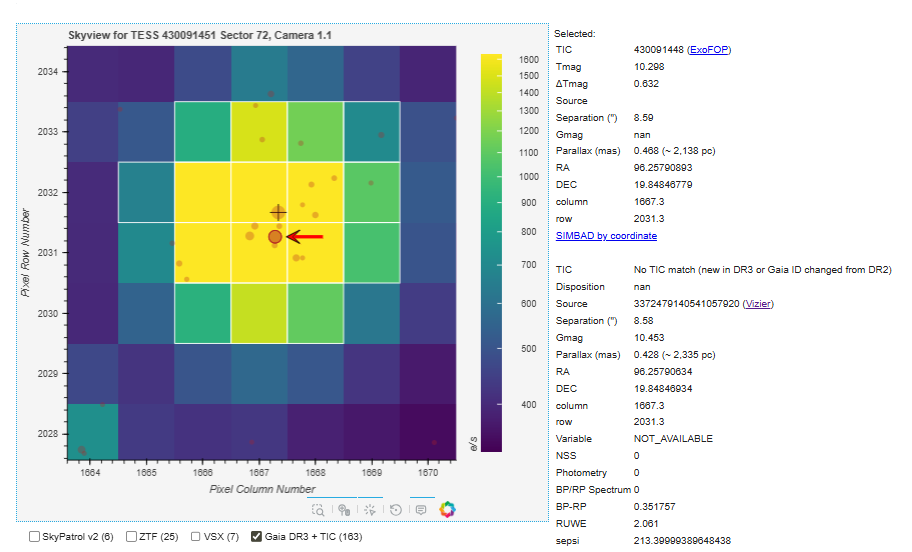

## Gaia DR3 info (coordinate, etc.)

In [6]:
# reload(lke)
# reload (lket)
rs_all_cols, rs, rs_html  = lket.search_gaiadr3_of_tics(tic, radius_arcsec=15, magnitude_range=None,  pm_error_factor=None, pm_range_fraction=None, pm_range_minimum=None, 
                                                        calc_separation_from_first_row=True,  # assuming the first row is the target, it'd calculate more accurately the separation for Gaia DR3 Main
                                                        compact_columns=True, also_return_html=True, also_return_astrophysical=False, verbose_html=True, include_nss_summary_in_html=False)
display(HTML(rs_html))

# from Gaia DR3
target_coord = SkyCoord(rs[0]["RAJ2000"], rs[0]["DEJ2000"], unit=(u.deg, u.deg), frame="icrs")
target_coord_dict = dict(ra=target_coord.ra.value, dec=target_coord.dec.value)


C:\dev\_juypter\PH_TESS_LightCurveViewer\targets\..\lightkurve_ext.py:2316: UserWarning: gaia_dr3_mag_to_vmag(): b_minus_r value (-1.803151) is outside the applicable range for the transformation. The result is probably not reliable.
  warnings.warn(
C:\dev\_juypter\PH_TESS_LightCurveViewer\targets\..\lightkurve_ext.py:2316: UserWarning: gaia_dr3_mag_to_vmag(): b_minus_r value (--) is outside the applicable range for the transformation. The result is probably not reliable.
  warnings.warn(


flag,_r,_p,Source,RPmag,Gmag,BPmag,BP-RP,Vmag,Teff,RUWE,sepsi,epsi,NSS,Plx,pmRA,pmDE,VarFlag,RV,e_RV,IPDfmp,Dup,RAJ2000,DEJ2000,EpochPh,EpochRV
,arcsec,deg,,mag,mag,mag,mag,mag,K,,,mas,,mas,mas / yr,mas / yr,,km / s,km / s,,,deg,deg,,
str2,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float32,float64,str48,float64,float64,float64,str34,float64,float32,int16,uint8,float64,float64,uint8,uint8
!!,0.000,0.0,<a target='vizier_gaia_dr3' href='https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-ref=VIZ6578bb1b54eda&-to=-4b&-from=-4&-this=-4&%2F%2Fsource=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fparamp&-out.max=50&%2F%2FCDSportal=http%3A%2F%2Fcdsportal.u-strasbg.fr%2FStoreVizierData.html&-out.form=HTML+Table&%2F%2Foutaddvalue=default&-order=I&-oc.form=sexa&-out.src=I%2F355%2Fgaiadr3%2CI%2F355%2Fparamp&-nav=cat%3AI%2F355%26tab%3A%7BI%2F355%2Fgaiadr3%7D%26tab%3A%7BI%2F355%2Fparamp%7D%26key%3Asource%3DI%2F355%2Fgaiadr3%26HTTPPRM%3A&-c=&-c.eq=J2000&-c.r=++2&-c.u=arcmin&-c.geom=r&-source=&-x.rs=10&-source=I%2F355%2Fgaiadr3+I%2F355%2Fparamp&-out.orig=standard&-out=RA_ICRS&-out=DE_ICRS&-out=Source&Source=3372479140541057920&-out=Plx&-out=PM&-out=pmRA&-out=pmDE&-out=sepsi&-out=IPDfmp&-out=RUWE&-out=Dup&-out=Gmag&-out=BPmag&-out=RPmag&-out=BP-RP&-out=RV&-out=e_RV&-out=VarFlag&-out=NSS&-out=XPcont&-out=XPsamp&-out=RVS&-out=EpochPh&-out=EpochRV&-out=MCMCGSP&-out=MCMCMSC&-out=Teff&-out=logg&-out=%5BFe%2FH%5D&-out=Dist&-out=A0&-out=HIP&-out=PS1&-out=SDSS13&-out=SKYM2&-out=TYC2&-out=URAT1&-out=AllWISE&-out=APASS9&-out=GSC23&-out=RAVE5&-out=2MASS&-out=RAVE6&-out=RAJ2000&-out=DEJ2000&-out=Pstar&-out=PWD&-out=Pbin&-out=ABP&-out=ARP&-out=GMAG&-out=Rad&-out=SpType-ELS&-out=Rad-Flame&-out=Lum-Flame&-out=Mass-Flame&-out=Age-Flame&-out=Flags-Flame&-out=Evol&-out=z-Flame&-meta.ucd=0&-meta=0&-usenav=1&-bmark=GET'>3372479140541057920,10.204,10.453,10.556,0.352,10.501,21520.5,2.061,213,0.475,0,0.4282,-0.752,0.263,NOT_AVAILABLE,--,--,44,0,96.25791163962,19.84846759143,0,0
!,2.997,95.7,<a target='vizier_gaia_dr3' href='https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-ref=VIZ6578bb1b54eda&-to=-4b&-from=-4&-this=-4&%2F%2Fsource=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fparamp&-out.max=50&%2F%2FCDSportal=http%3A%2F%2Fcdsportal.u-strasbg.fr%2FStoreVizierData.html&-out.form=HTML+Table&%2F%2Foutaddvalue=default&-order=I&-oc.form=sexa&-out.src=I%2F355%2Fgaiadr3%2CI%2F355%2Fparamp&-nav=cat%3AI%2F355%26tab%3A%7BI%2F355%2Fgaiadr3%7D%26tab%3A%7BI%2F355%2Fparamp%7D%26key%3Asource%3DI%2F355%2Fgaiadr3%26HTTPPRM%3A&-c=&-c.eq=J2000&-c.r=++2&-c.u=arcmin&-c.geom=r&-source=&-x.rs=10&-source=I%2F355%2Fgaiadr3+I%2F355%2Fparamp&-out.orig=standard&-out=RA_ICRS&-out=DE_ICRS&-out=Source&Source=3372479140535033600&-out=Plx&-out=PM&-out=pmRA&-out=pmDE&-out=sepsi&-out=IPDfmp&-out=RUWE&-out=Dup&-out=Gmag&-out=BPmag&-out=RPmag&-out=BP-RP&-out=RV&-out=e_RV&-out=VarFlag&-out=NSS&-out=XPcont&-out=XPsamp&-out=RVS&-out=EpochPh&-out=EpochRV&-out=MCMCGSP&-out=MCMCMSC&-out=Teff&-out=logg&-out=%5BFe%2FH%5D&-out=Dist&-out=A0&-out=HIP&-out=PS1&-out=SDSS13&-out=SKYM2&-out=TYC2&-out=URAT1&-out=AllWISE&-out=APASS9&-out=GSC23&-out=RAVE5&-out=2MASS&-out=RAVE6&-out=RAJ2000&-out=DEJ2000&-out=Pstar&-out=PWD&-out=Pbin&-out=ABP&-out=ARP&-out=GMAG&-out=Rad&-out=SpType-ELS&-out=Rad-Flame&-out=Lum-Flame&-out=Mass-Flame&-out=Age-Flame&-out=Flags-Flame&-out=Evol&-out=z-Flame&-meta.ucd=0&-meta=0&-usenav=1&-bmark=GET'>3372479140535033600,14.833,15.844,15.249,0.416,15.902,--,1.230,5.26,0.249,0,0.1190,-0.270,-0.516,NOT_AVAILABLE,--,--,0,0,96.25879004727,19.84838780331,0,0
,4.014,295.8,<a target='vizier_gaia_dr3' href='https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-ref=VIZ6578bb1b54eda&-to=-4b&-from=-4&-this=-4&%2F%2Fsource=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fparamp&-out.max=50&%2F%2FCDSportal=http%3A%2F%2Fcdsportal.u-strasbg.fr%2FStoreVizierData.html&-out.form=HTML+Table&%2F%2Foutaddvalue=default&-o

In [10]:
primary_name = f"TIC {tic}" # bright star but has no HD name, probably due to the brighter nearby star
primary_name

'TIC 430091448'

## Combining all data (TESS only)

- ASAS-3 : data does not have the photometric precision
  - https://www.astrouw.edu.pl/cgi-asas/asas_variable/062502+1950.9,asas3,35.5524,-4502.27,500,900,0
- ASAS-SN SkyPatrol: probably does not have the photometric precision either


### TESS: remove outliers / systemaitcs; convert to mag and HJD


In [20]:
# helper to review the data interactively
tplt.plot_transit_interactive(_lc, figsize=(30, 8), plot_kwargs=dict(normalize=False, plot_kwargs=dict(s=25),));

Output(layout=Layout(border_bottom='1px solid lightgray', border_left='1px solid lightgray', border_right='1px…

Output(layout=Layout(padding='1em'))

28869

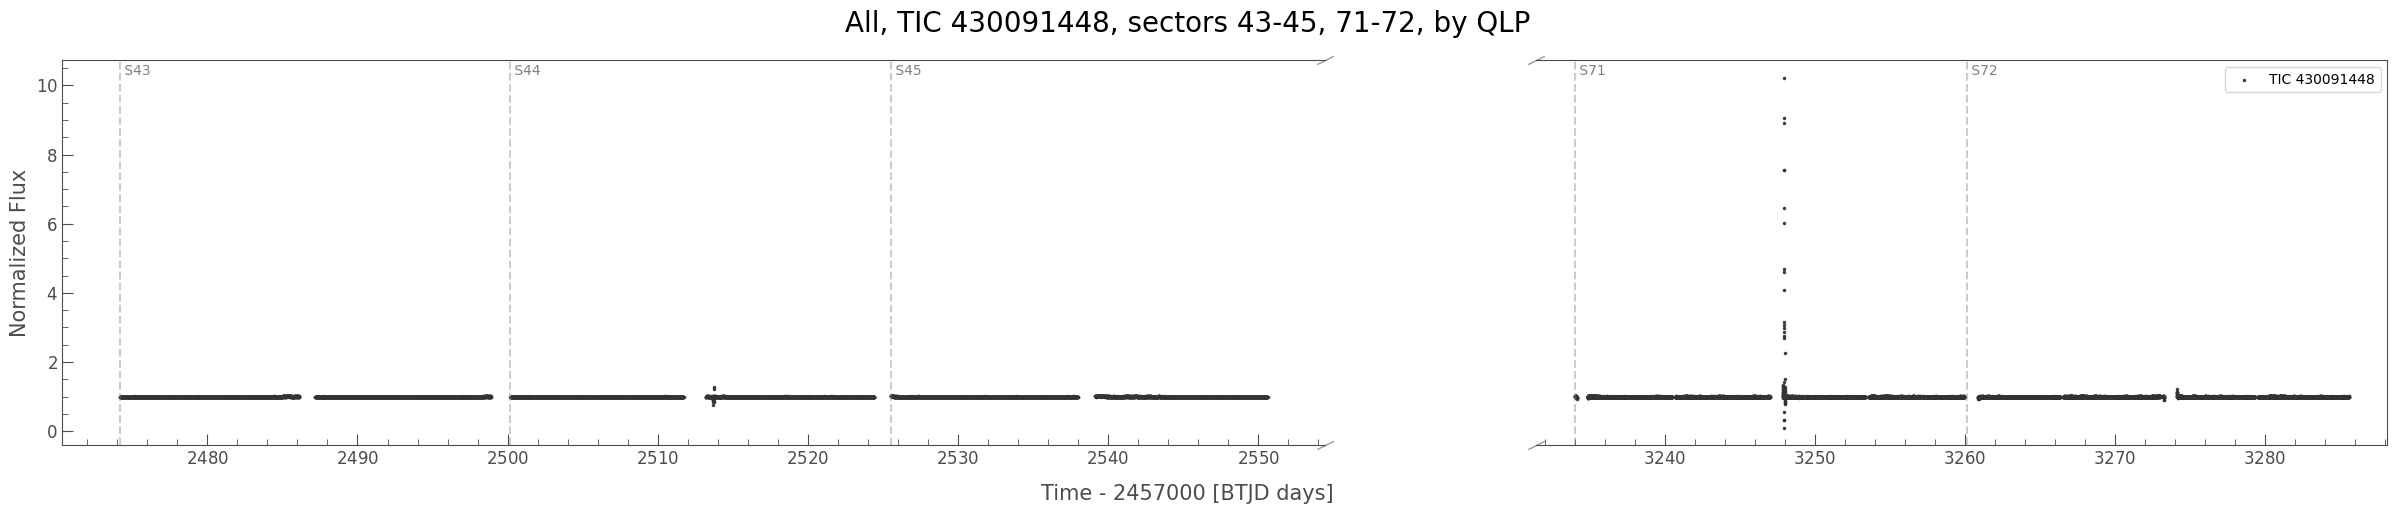

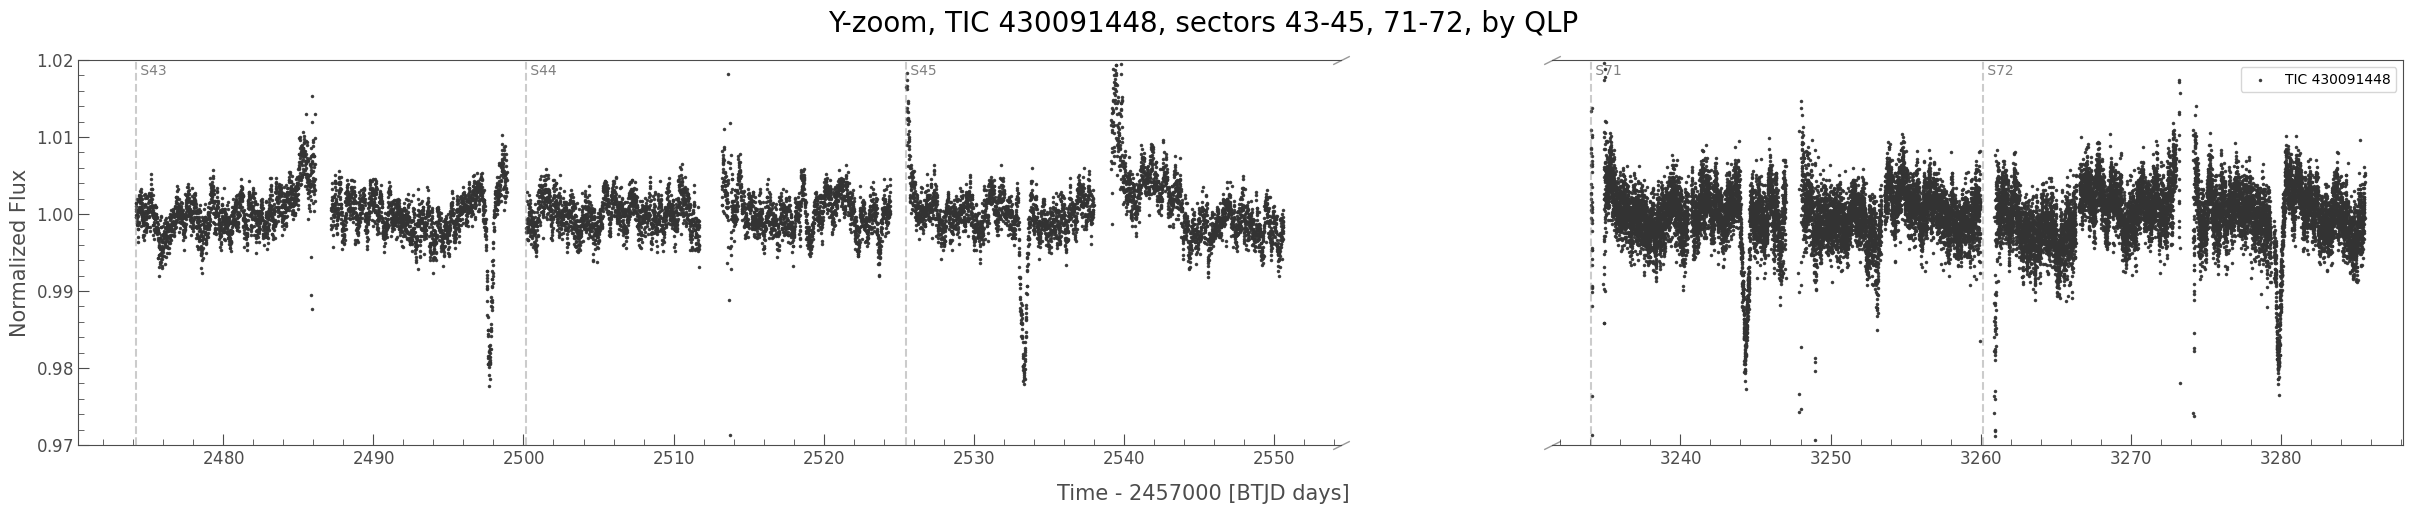

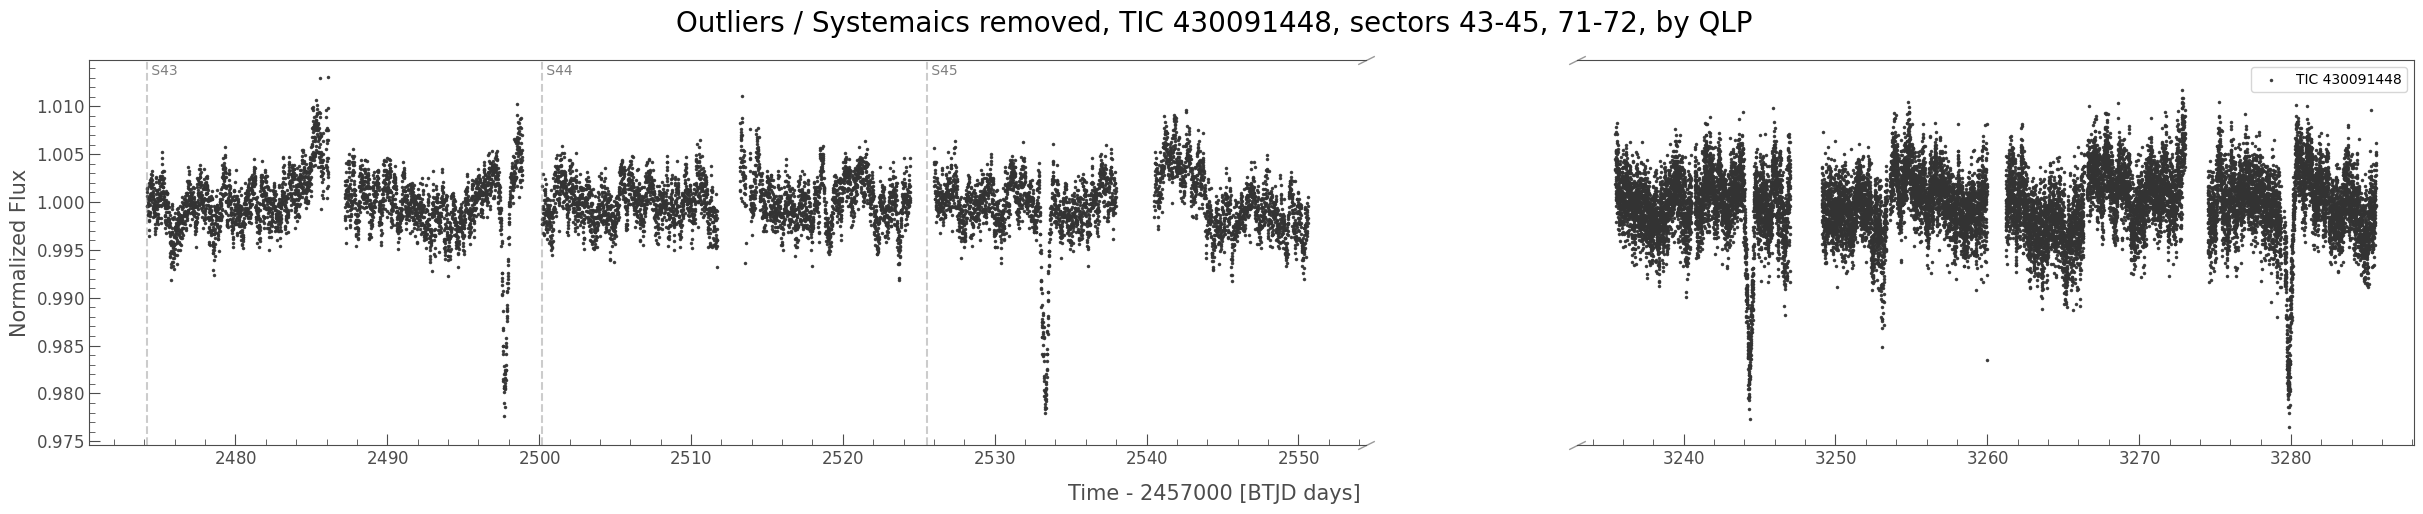

In [4]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True)  # , corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"All, {_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"Y-zoom, {_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);
[ax.set_ylim(0.97, 1.02) for ax in axs];

_lc = _lc.truncate(0.97, 1.02, column="flux");

for xstart, xstop in [  # scattered light, and systematics
    (2485.8, 2485.95),
    (2513.6, 2513.85),
    (2525.4, 2526),
    (2539.0, 2540.5),
    (3234, 3235.5), 
    (3247.7, 3249.1), 
    (3260.8, 3261.2),
    (3273.2, 3274.5), 
    
]:
    _lc = lke.exclude_range(_lc, xstart, xstop)

# # QLP sector 18 data has lone outliers associated with momentum dumps, exclude the time around them
# for t in np.unique(np.round(lket.MomentumDumpsAccessor.get_in_range(start=1790, end=1816), 2)):
#     _lc = lke.exclude_range(_lc, t - 0.05, t + 0.05)

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"Outliers / Systemaics removed, {_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);


# convert to mag and HJD
lc_tess = _lc
lc_tess = lke.to_flux_in_mag_by_normalization(lc_tess)
lc_tess = lke.convert_lc_time_to_hjd_utc(lc_tess, target_coord=target_coord, cache_dir=lk_download_dir)
len(lc_tess)

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

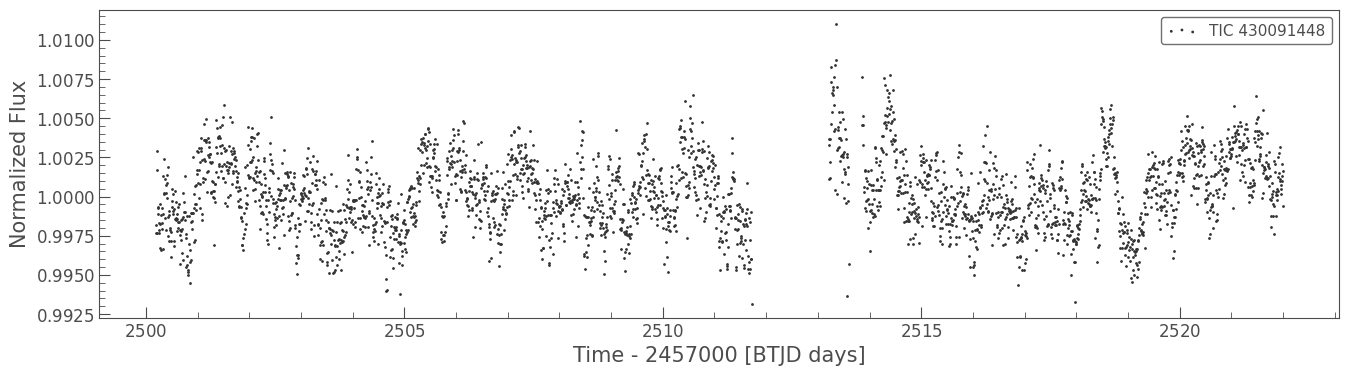

In [14]:
ax = tplt.scatter(_lc.truncate(2500, 2522), figsize=(16, 4))
ax

### Do Actual combining

TESS # data points: 28869


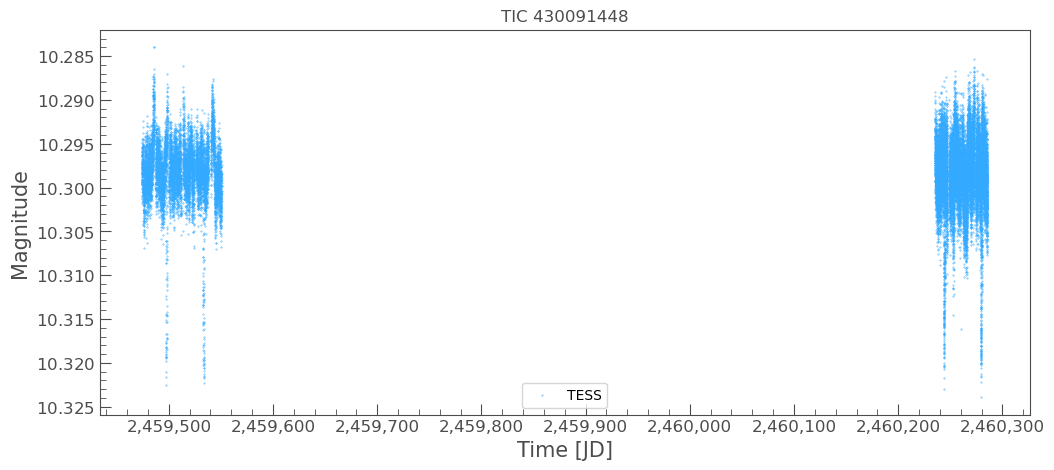

In [27]:
# Convert the data to magnitude and HJD/UTC

import lightkurve_ext_multi_sources as lkem
# reload(lkem)

lc_combined_dict = lkem.combine_multi_bands_and_shift(
    {"TESS": lc_tess, 
    }, 
    # shift_to="",
)

for k in lc_combined_dict.keys():
    print(f"{k} # data points:", len(lc_combined_dict[k]))

plot_options = lkem.get_default_plot_multi_bands_options_copy()
# for TESS plot (index 0) move it to the front
# plot_options[0][1]["zorder"] = 3  # default 2

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(12, 5), target_name=primary_name, plot_options=plot_options);
# ax.set_ylim(10.4, 10.25);

## Initial epoch / period / duration


Adopted period / epoch / duration_hr:  35.55 2459497.73 20.0


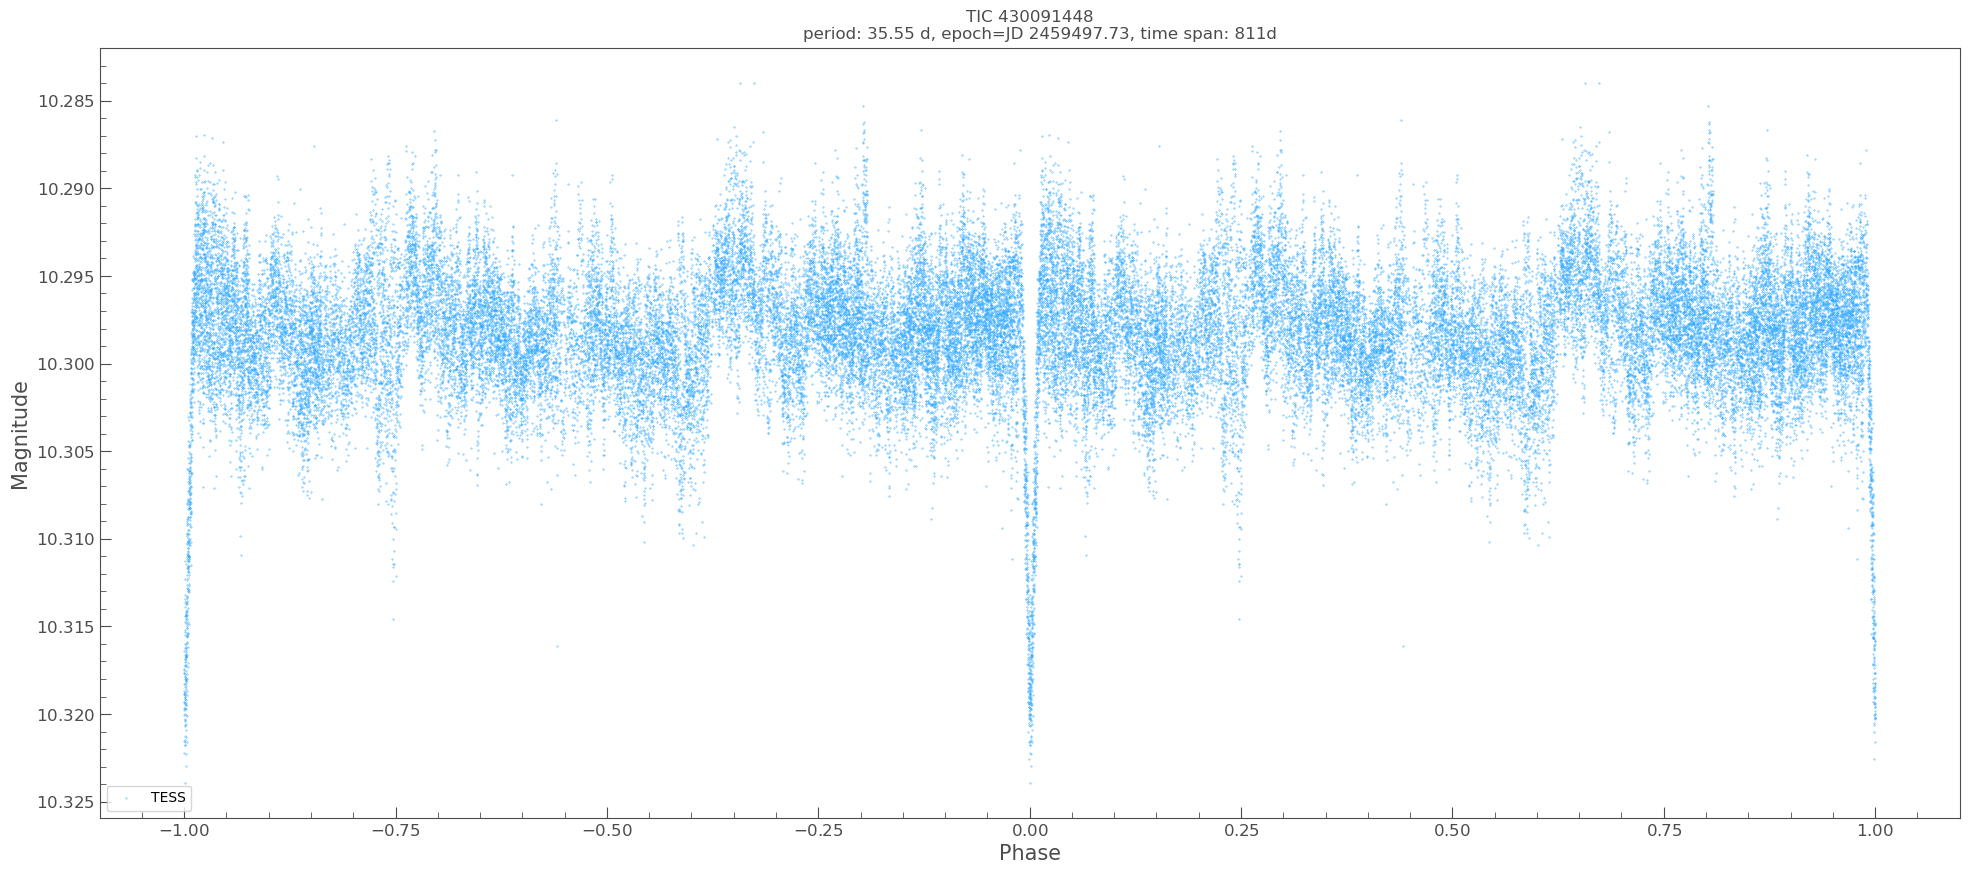

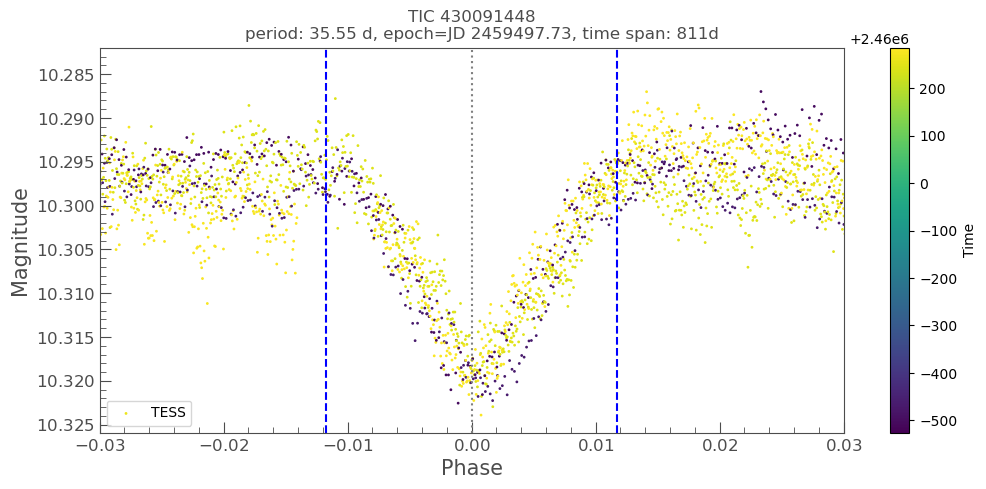

In [39]:
# reload(lkem)

# from the TCE of the brigher contaminant 
#  https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:TESS/product/tess2018235142541-s0002-s0072-0000000430091451-01-00829_dvs.pdf
#  epoch=2497.73, duration_hr=15.6203, period=35.5524, label="s0002s0072tce1", transit_depth_percent=0.7728,

period_trial = 35.55  # adjusted from TCE value 35.5524, with obvious mialignemnet
epoch_time_btjd_trial = 2497.73  # TCE value 
epoch_time_hjd_trial = round(lket.btjd_to_hjd_utc(epoch_time_btjd_trial, target_coord), 2)  # need 3 digit to ensure it does look off visually
duration_hr_min_i_trial = 20.0

# # from visual inspection
# epoch_time_min_ii_btjd_trial = 
# epoch_time_min_ii_hjd_trial = round(lket.btjd_to_hjd_utc(epoch_time_min_ii_btjd_trial, target_coord), 2)  # need 3 digit to ensure it does look off visually
# duration_hr_min_ii_trial = 18.5


print("Adopted period / epoch / duration_hr: ", period_trial, epoch_time_hjd_trial, duration_hr_min_i_trial)  # , duration_hr_min_ii_trial

# --- Plot them to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 1
plot_options_zoom[0][1]["c"] = "_time_"

# plot_options_zoom[0][1]["zorder"] = 3  # move to the front, default 2
# plot_options_zoom[1][1].update(dict(marker='o', markersize=4))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_trial  ,  # for plotting only
    figsize=(12, 5), 
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.03, 0.03);  # to see primary in details
ax.set_ylim(*ylim);


# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_trial,
#     epoch=Time(epoch_time_min_ii_hjd_trial, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     duration_hr=duration_hr_min_ii_trial  ,  # for plotting only
#     figsize=(12, 5),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_xlim(-0.015, 0.015);  # to see primary in details
# ax.set_ylim(9.3, None);


## Period refinement with MCMC

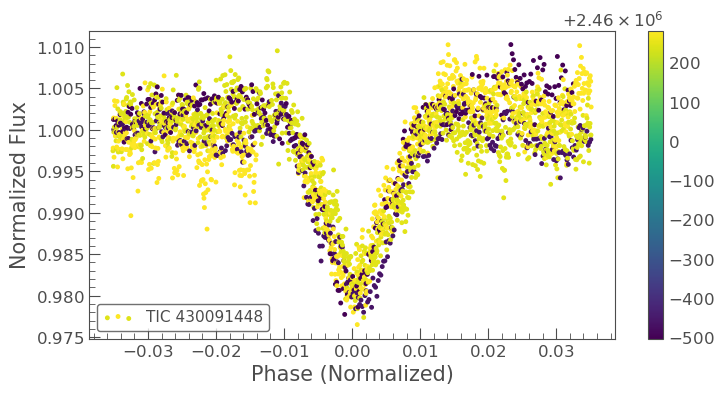

In [41]:
_lc = lke.stitch_lc_dict(lke.get_lc_dict_subset(lc_combined_dict, "TESS"), normalize=True).remove_nans()  

lc_f_min_i = _lc.fold(epoch_time=epoch_time_hjd_trial, period=period_trial, normalize_phase=True)
lc_f_min_i = lc_f_min_i.truncate((0 - duration_hr_min_i_trial / 24 * 1.5) / period_trial, (0 + duration_hr_min_i_trial /24 * 1.5) / period_trial)
# lc_f_min_i = lc_f_min_i.truncate(None, 1.2, column="flux")  # crude outlier removal
ax1 = tplt.scatter(lc_f_min_i, c=lc_f_min_i.time_original.value, s=25);
# ax1 = tplt.errorbar(lc_f_min_i);

In [43]:
from types import SimpleNamespace

import sys
if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
    sys.path.append("../eb_with_diff_sb_period/etv/")

import etv_functions_with_period as etvp
import etv_functions
# reload(etv_functions)

lc_f = lc_f_min_i

# # median flux, -eclipse depth, t0, related to duration, related to shape (U or V) 
# # t0 in normalixed phase
start_vals = [1.0, -0.02, 0, 0.005, 0.8]


# convert lc to the form needed by fit etv_functions
lc_f_data = SimpleNamespace(time=lc_f.time_original.value, phase=lc_f.time.value, flux=np.array(lc_f.flux.value), err=np.array(lc_f.flux_err.value))
etv_functions.plot_initial_guess_interactive(lc_f_data, None, None, None, "0", *start_vals)

Output(layout=Layout(padding='1em 0px'), outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Fig…

Output(layout=Layout(padding='1em'), outputs=({'name': 'stdout', 'text': '[1.0, -0.02, 0, 0.005, 0.8]\n\n', 'o…

###  Trial to see if a slightly different initial period (the TCE period) will yield a different final period

- No, it still converges to same final period

100%|██████████████████████████████████████████████████████████| 2000/2000 [02:45<00:00, 12.11it/s]


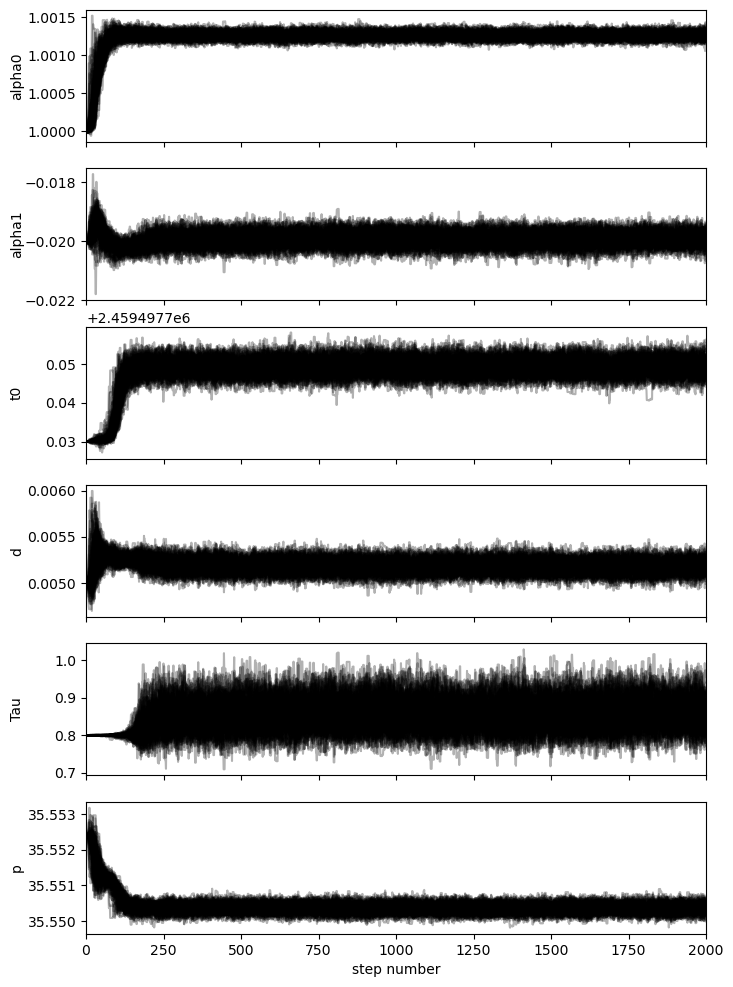

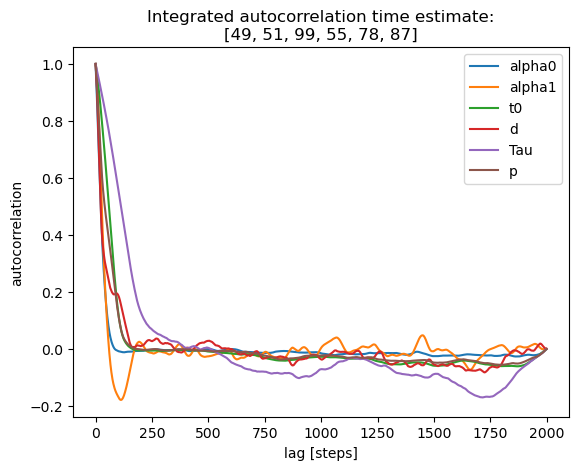

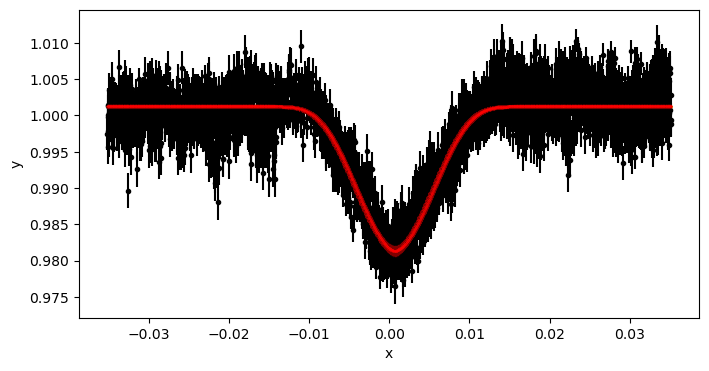

mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = 1.0012572091231862, -0.019922261556923962, 2459497.74929859, 0.0051796473684757125, 0.8558808134296043, 35.55035844297731
std_t0: 0.002050912863758887
std_p: 0.0001287321314947287


In [53]:
# Trial to see if a different initial period (the TCE period) will yield a very different final period
mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p, fit_params_p_stats  = etvp.run_mcmc_initial_fit_p(
    lc_f_data, 
    [1.0, -0.02, epoch_time_hjd_trial, 0.005, 0.8, 35.5524], # period_trial
    # nruns=20, discard=1,
    nruns=2000, discard=1000,
    autocorr_time_kwargs=dict(tol=20),  # the emcee defaults tol=50 seems to be too strict for our use case, tol of ~10 - 20 seems to be sufficient    
    pool=-2, 
    plot_chains=True, plot_autocorrelation=True, plot=True, 
    also_return_stats=True,
)

print("mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = " + ", ".join([str(v) for v in [mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p]]))
print("std_t0:", fit_params_p_stats["std_t0"])
print("std_p:", fit_params_p_stats["std_p"])


### Final MCMC fit with the best initial period

100%|██████████████████████████████████████████████████████████| 4000/4000 [05:20<00:00, 12.49it/s]


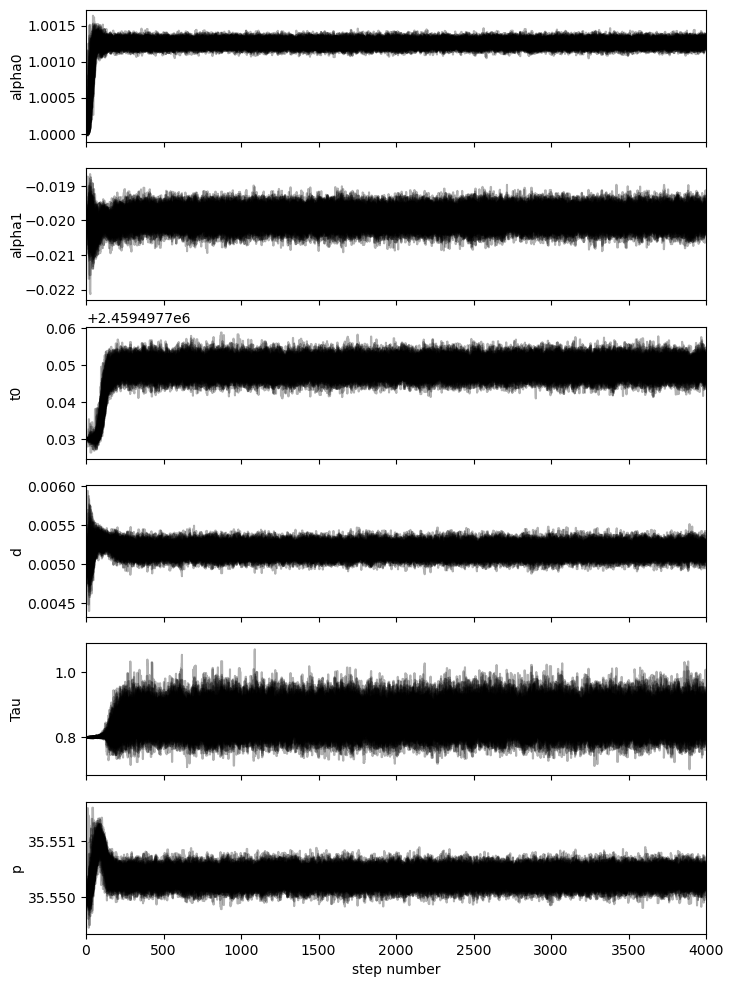

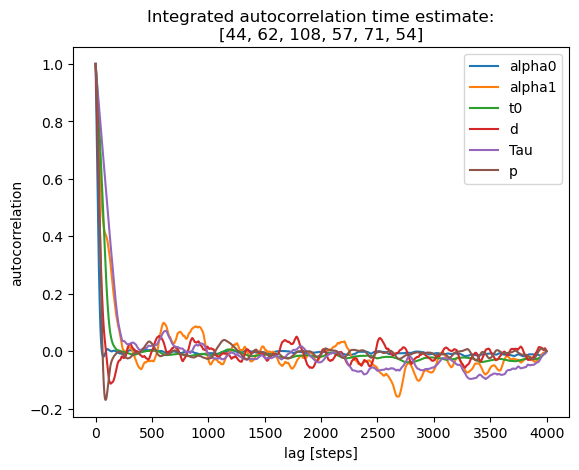

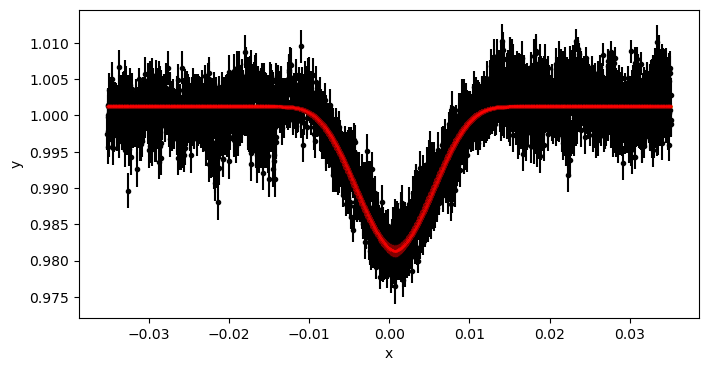

mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = 1.0012554736581603, -0.019908758639415297, 2459497.7493316326, 0.005176656023250129, 0.8582063722626141, 35.550357663349374
std_t0: 0.0020503626616495308
std_p: 0.00012748393665182862


In [45]:
mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p, fit_params_p_stats  = etvp.run_mcmc_initial_fit_p(
    lc_f_data, 
    [1.0, -0.02, epoch_time_hjd_trial, 0.005, 0.8, period_trial],
    # nruns=20, discard=1,
    nruns=4000, discard=1000,
    autocorr_time_kwargs=dict(tol=20),  # the emcee defaults tol=50 seems to be too strict for our use case, tol of ~10 - 20 seems to be sufficient    
    pool=-2, 
    plot_chains=True, plot_autocorrelation=True, plot=True, 
    also_return_stats=True,
)

print("mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = " + ", ".join([str(v) for v in [mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p]]))
print("std_t0:", fit_params_p_stats["std_t0"])
print("std_p:", fit_params_p_stats["std_p"])


## Final period / epoch / duration

Adopted period / epoch / duration_hr:  35.550 2459497.75 20.0


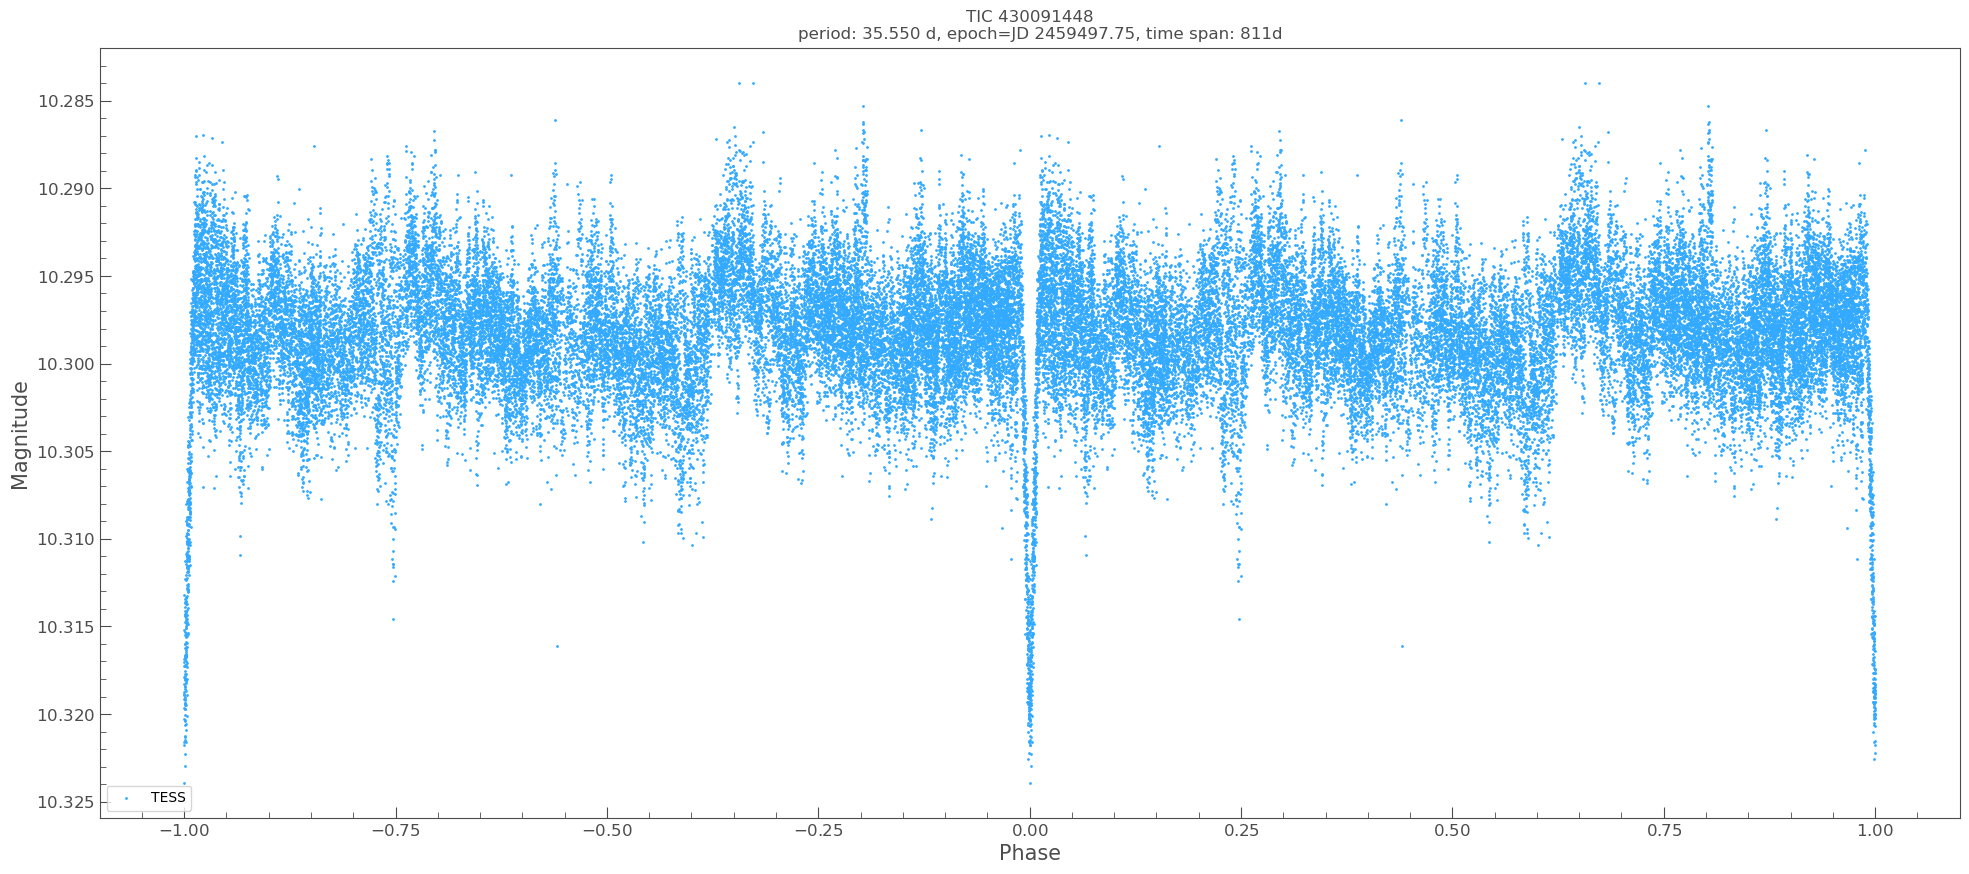

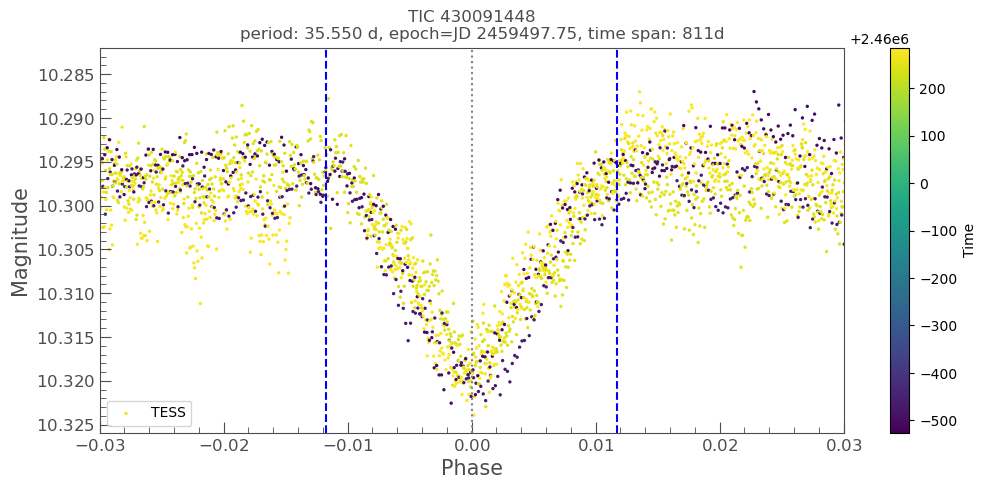

In [54]:
# reload(lkem)
from decimal import Decimal

# MCMC values: p=35.550357663349374, std_p: 0.00012748393665182862  ; t0 = 2459497.7493316326, std_t0: 0.0020503626616495308
period_final = Decimal("35.550")
epoch_time_hjd_final = 2459497.75
duration_hr_min_i_final = duration_hr_min_i_trial 

# epoch_time_min_ii_hjd_final = epoch_time_min_ii_hjd_trial
# epoch_phase_min_ii_final   = abs(epoch_time_min_ii_hjd_final - float(epoch_time_hjd_final)  ) / period_final  % 1
# epoch_phase_min_ii_final  = round(epoch_phase_min_ii_final, 4)  # precsion from eyeballing zoomed plot
# duration_hr_min_ii_final = duration_hr_min_ii_trial


print("Adopted period / epoch / duration_hr: ", period_final, epoch_time_hjd_final, duration_hr_min_i_final)  #  epoch_phase_min_ii_final, , duration_hr_min_ii_final

# --- plot to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[0][1]["s"] = 1

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 2
plot_options_zoom[0][1]["c"] = "_time_"


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.03, 0.03);  # to see primary in details
ax.set_ylim(*ylim);

# ax = tplt.scatter(lc_f_res["TESS"].truncate(-0.005, 0.005), c="#3AF");
# ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_title(f"Min I: {epoch_time_hjd_final}");

# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_final,
#     epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     duration_hr=duration_hr_min_ii_final  ,  # for plotting only
#     duration_midpoint_phase=epoch_phase_min_ii_final,
#     figsize=(12, 5),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
# ax.set_xlim(epoch_phase_min_ii_final - 0.01, epoch_phase_min_ii_final + 0.01);  # to see secondary in details
# ax.set_ylim(9.3, None);


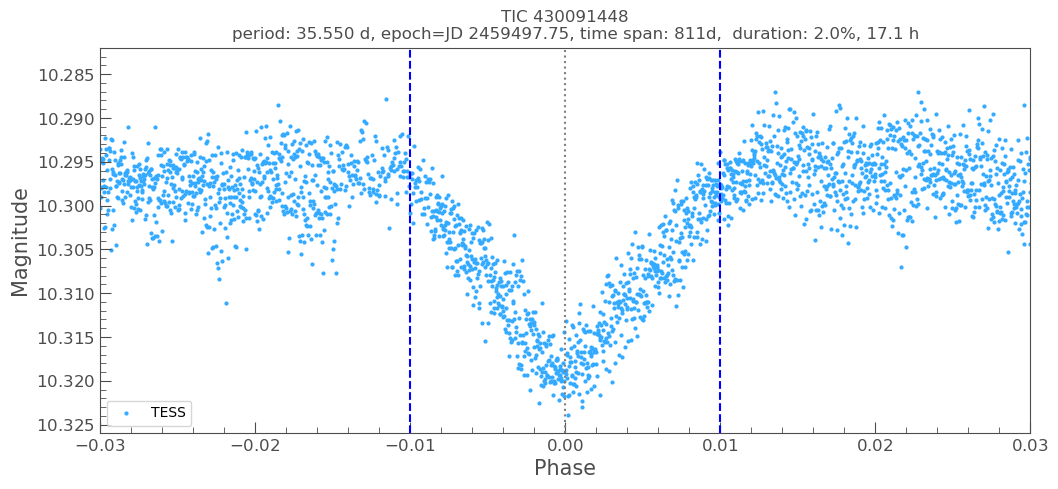

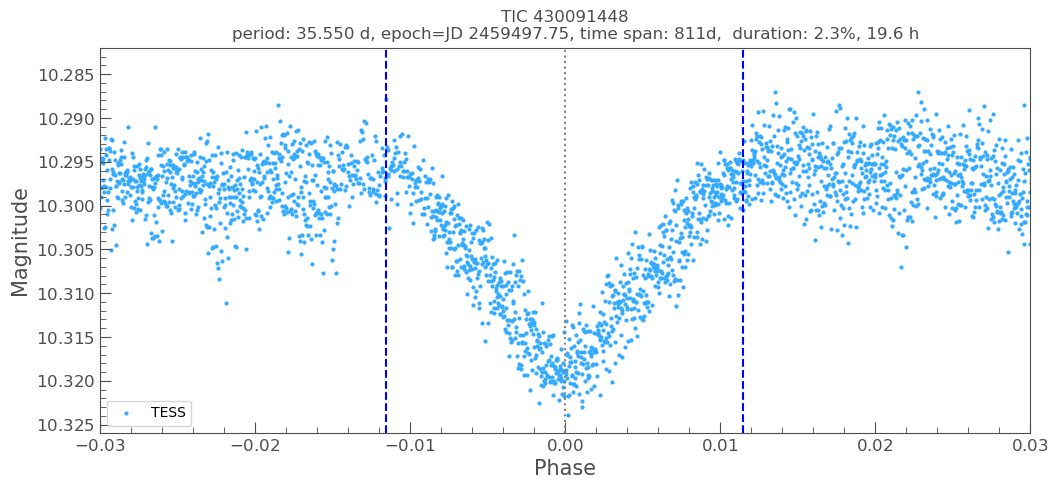

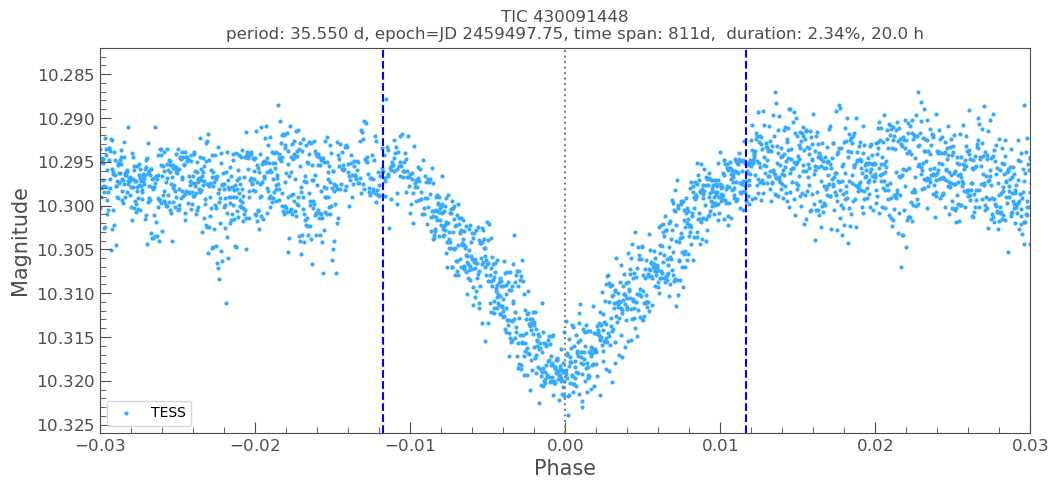

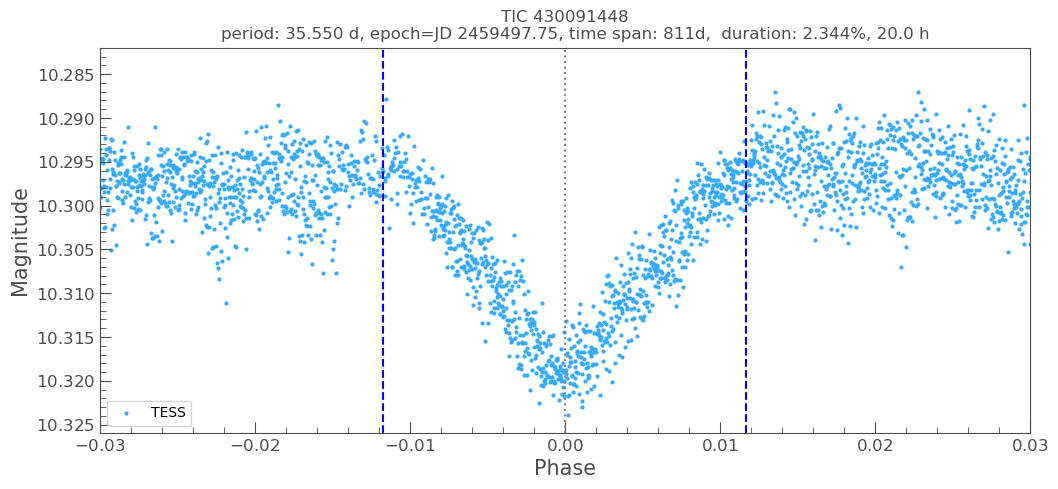

In [83]:
# demonstrate the precision difference in duration percentage 
# - 1 digit for percetnarge would be appropriate
for _precision in [0, 1, 2, 3]: 
    _dur_pct = round(100 * duration_hr_min_i_final / 24 / float(period_final), _precision)
    _dur_hr = _dur_pct /100 * 24 * float(period_final)
    # zoom plot Min I
    # - make TESS more visible:  larger dots
    plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
    plot_options_zoom[0][1]["s"] = 4
    ax, lc_f_res = lkem.fold_n_plot_multi_bands(
        lc_combined_dict,
        period=period_final,
        epoch=Time(epoch_time_hjd_final  , format="jd", scale="utc"),
        phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
        target_name=primary_name,
        duration_hr=_dur_hr,  # for plotting only
        figsize=(12, 5),
        plot_options=plot_options_zoom,
        # mag_shift_precision=2,  #
    );
    ax.set_ylim(*ylim);
    ax.legend(loc="lower left");
    ax.axvline(0, c="gray", linestyle="dotted");
    ax.set_xlim(-0.03, 0.03);  # to see primary in details
    ax.set_title(ax.get_title() + f",  duration: {_dur_pct}%, {_dur_hr:.1f} h");
    # print(_dur_pct, _dur_hr, duration_hr_min_i_final) 

## Determine Amplitude (TESS)


Min I mag # num data points: 13
['10.2981', '10.3189']


(0.023,)

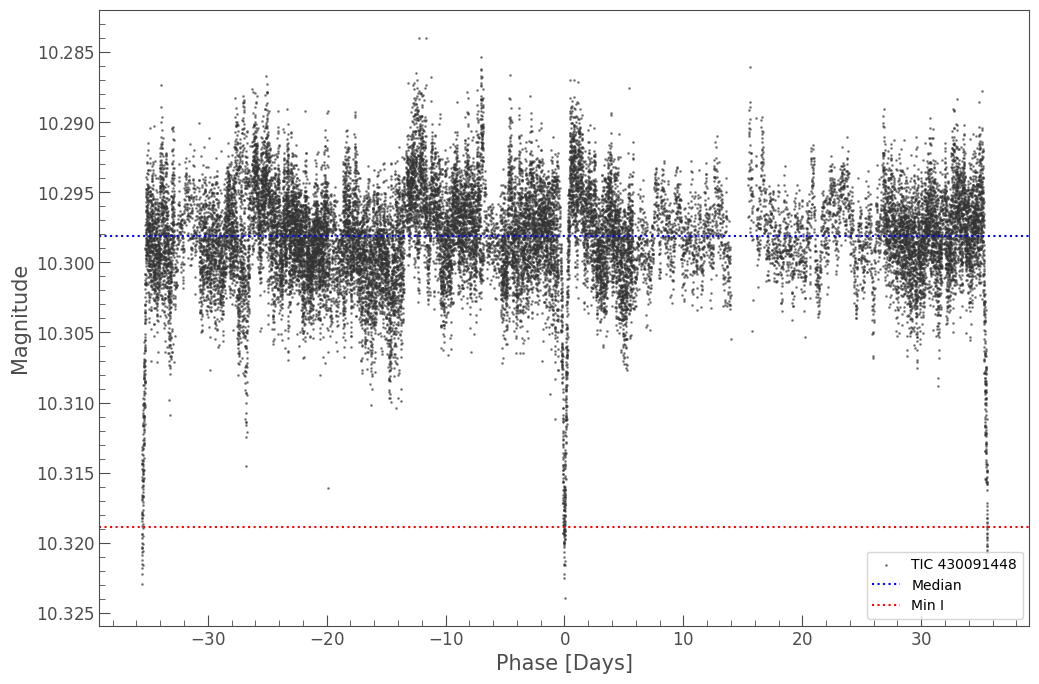

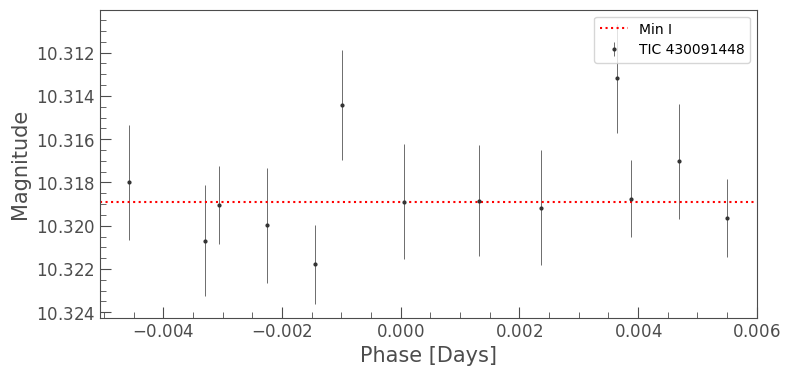

In [5]:
# %matplotlib widget
%matplotlib inline

# From TESS data
lc = lc_combined_dict["TESS"]

# max_flux_mag = lc.flux.min().value  #
# min_flux_mag = lc.flux.max().value
median_flux_mag = np.nanmedian(lc.flux.value)

# no max neded, medain is basically max
# lc_zoom_max = lc.fold(epoch_time=epoch_time_hjd_final + 0.75, period=period_final).truncate(0 - 1 /24/60, 0 + 1 /24/ 60)  
# print("Max mag # num data points:", len(lc_zoom_max))
# max_flux_mag = np.nanmedian(lc_zoom_max.flux.value)

lc_zoom_min = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final).truncate(0 - 8 /24/60, 0 + 8 /24/ 60)
print("Min I mag # num data points:", len(lc_zoom_min))
min_flux_mag = np.nanmedian(lc_zoom_min.flux.value)

# lc_zoom_min_ii = lc.fold(epoch_time=epoch_time_min_ii_hjd_final, period=period_final).truncate(0 - 4 /24/60, 0 + 4 /24/ 60)
# print("Min II mag # num data points:", len(lc_zoom_min_ii))
# min_ii_flux_mag = np.nanmedian(lc_zoom_min_ii.flux.value)


lc_f = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final * 2)  # 2x period plot
ax = tplt.lk_ax(figsize=(12, 8))
ax = tplt.scatter(lc_f, ax=ax, alpha=0.5);
# ax.axhline(max_flux_mag, c="purple", linestyle="--", label="Max")
ax.axhline(median_flux_mag, c="blue", linestyle="dotted", label="Median")
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I")
# ax.axhline(min_ii_flux_mag, c="orange", linestyle="dotted", label="Min II")
ax.legend(loc="lower right");
# ax.set_xlim(-0.5, 0.5); 
ax.set_ylim(*ylim);


ax = tplt.errorbar(lc_zoom_min, marker="o");
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I")
# ax.set_ylim(*ylim);
ax.legend();

# ax = tplt.errorbar(lc_zoom_min_ii, marker="o");
# ax.axhline(min_ii_flux_mag, c="red", linestyle="dotted", label="Min II")
# ax.legend(loc="lower right");

print([f"{v:.4f}" for v in [median_flux_mag, min_flux_mag]])  # , min_ii_flux_mag


# # TESS only data, to report mean V mag and ampitude in TESS
# mean_flux_v_mag = np.round(rs_all_cols["Vmag"][0], 2)  # V converted from Gaia DR3 - here I use other sources

# amp_flux_mag = np.round(np.abs(float(min_flux_mag - max_flux_mag)) , 3)  # in TESS band, probably don't have 4 digit precison

amp_min_i_flux_mag = np.round(np.abs(float(min_flux_mag - median_flux_mag)) , 3)  # does not look like it has 3 digit precision given the out-of-eclipse variation

# amp_min_ii_flux_mag = np.round(np.abs(float(min_ii_flux_mag - median_flux_mag)) , 2)  

amp_min_i_flux_mag = 0.023  # suggestion from SO, overriding
(amp_min_i_flux_mag, )  # amp_flux_mag, amp_min_ii_flux_mag

### Maximum / Median magnitude in V 

- GCPD data is blended of the target and the nearby star. So use Gaia DR3 
- GCPD entry: https://vizier.cds.unistra.fr/viz-bin/VizieR-5?-ref=VIZ6a17694f2562ff&-out.add=.&-source=II/167/catalog&recno=152774

In [65]:
median_flux_vmag = Decimal("10.50")  # from Gaia DR3
median_flux_vmag

Decimal('10.50')

## Plots for VSX

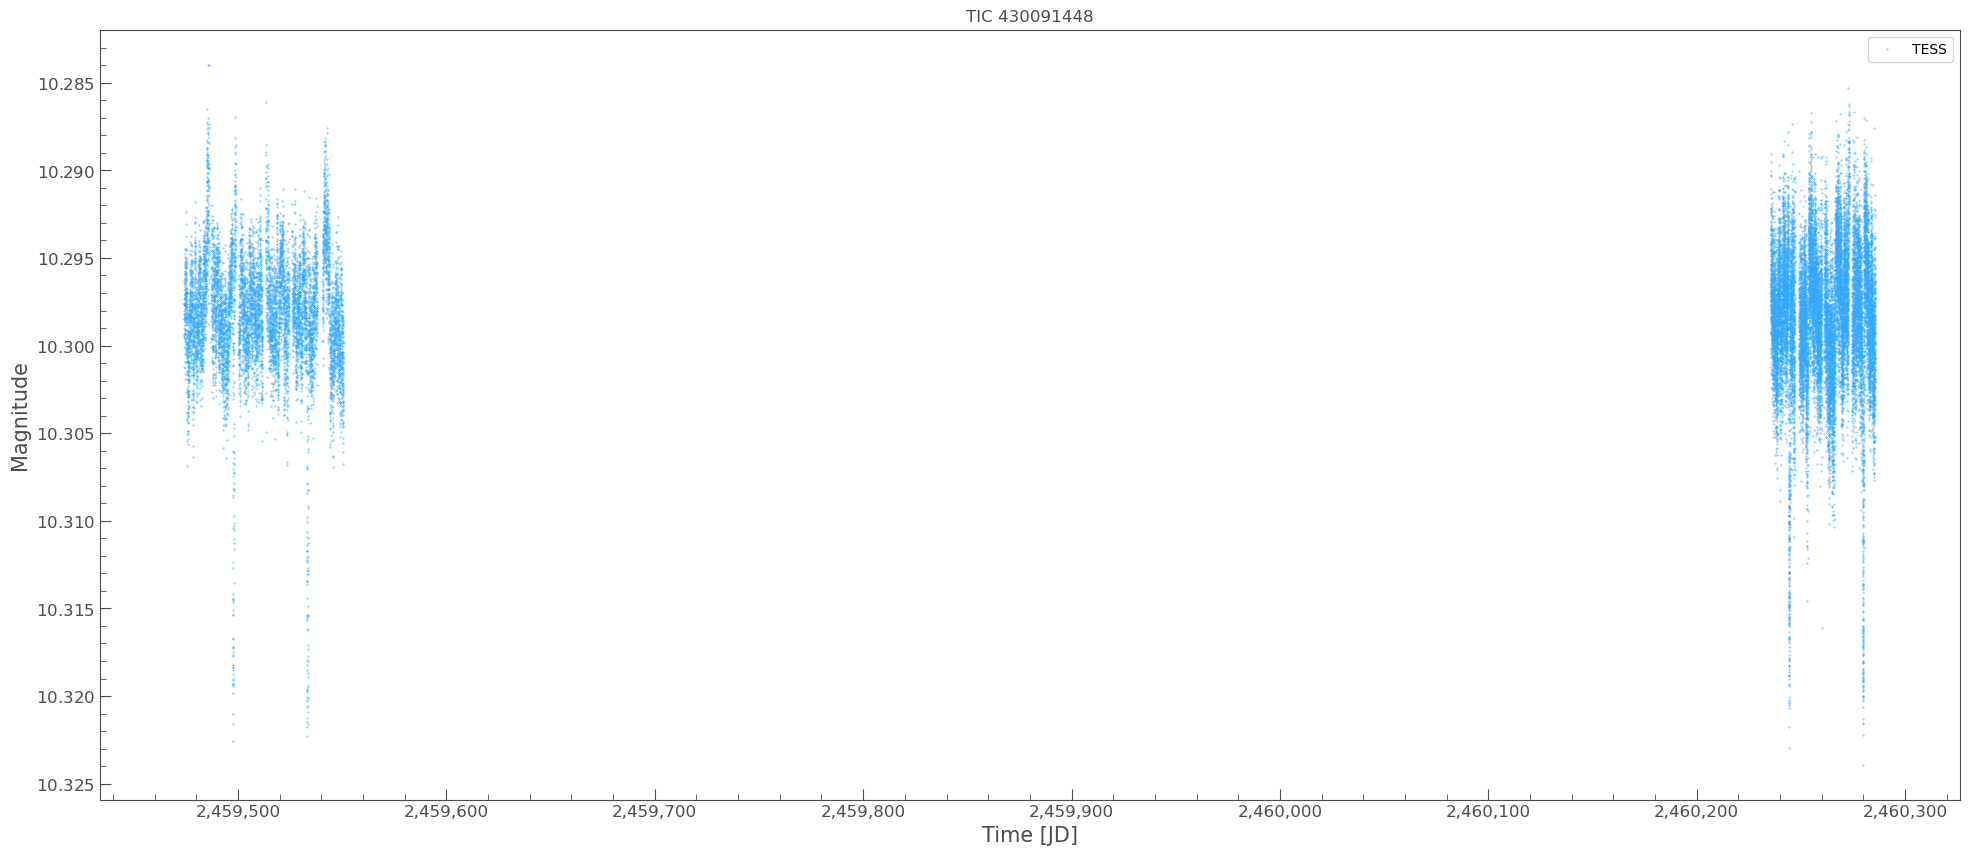

In [66]:
# reload(lkem)
# Not needed
plot_options = lkem.get_default_plot_multi_bands_options_copy()
# plot_options[0][1]["zorder"] = 4

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(24, 10), target_name=primary_name, plot_options=plot_options);
# ax.set_title(ax.get_title() + "");

#### Phase Plot



In [ ]:
lkem.get_default_plot_multi_bands_options_copy()

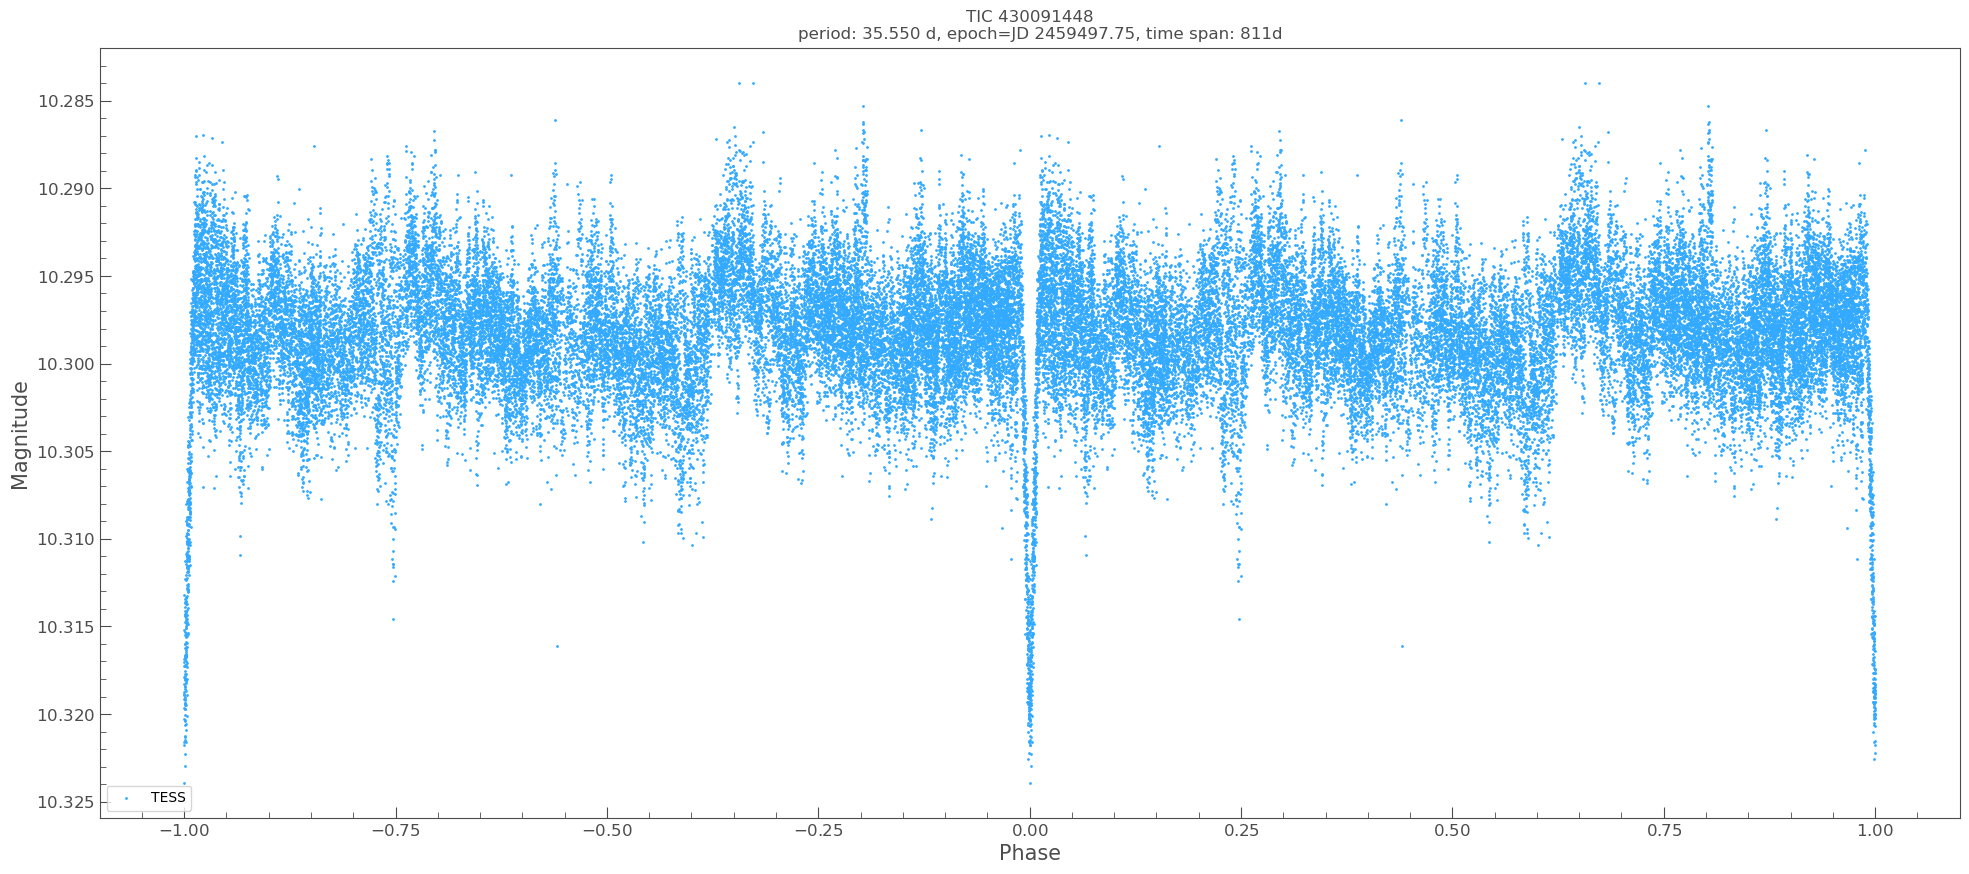

In [67]:
plot_options = lkem.get_default_plot_multi_bands_options_copy()  # use scatter plot , as errrobar is too busy
plot_options[0][1].update(dict(s=1, ))  # make dots larger

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)  # hide the outliers that are too bright, mostly in ASAS-SN g
ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", outliers truncated");


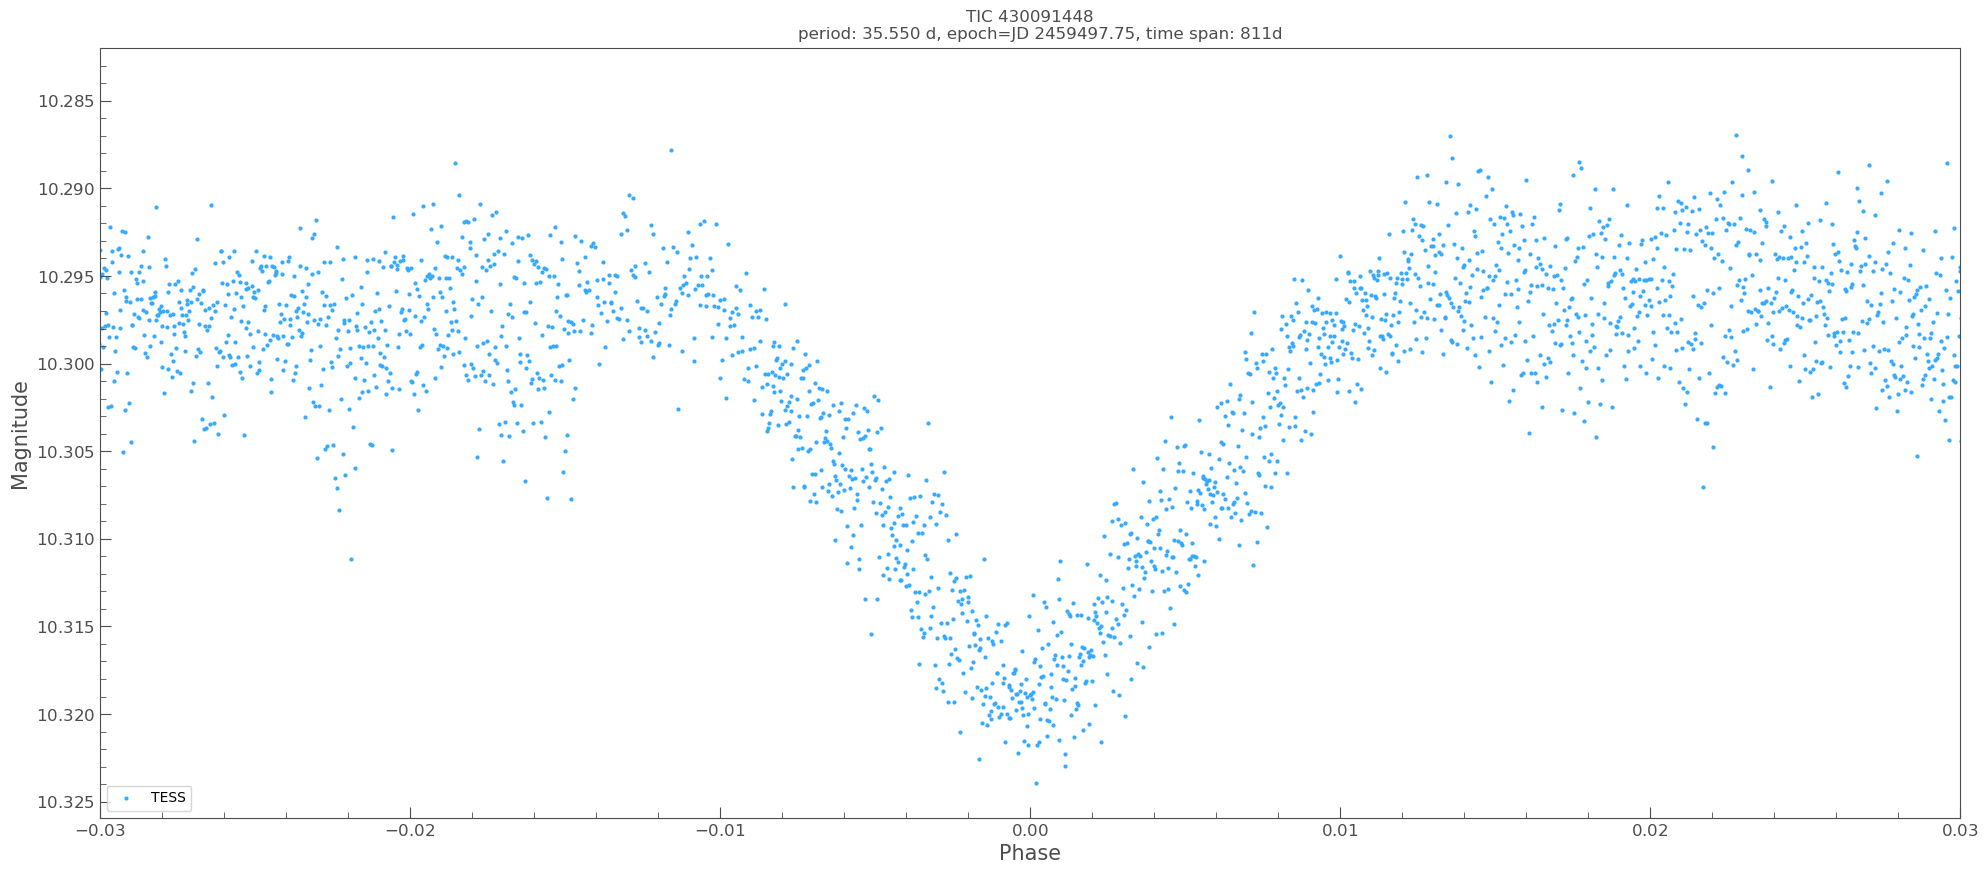

In [68]:
# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1].update(dict(s=4))
plot_options_zoom[1][1].update(dict(marker='o', markersize=9))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    # duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(24, 10),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
# ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.03, 0.03);  # to see primary in details
ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", outliers truncated");


# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_final,
#     epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     # duration_hr=duration_hr_min_ii_final ,  # for plotting only
#     # duration_midpoint_phase=epoch_phase_min_ii_final,
#     figsize=(24, 10),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# # ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
# ax.set_xlim(epoch_phase_min_ii_final - 0.01, epoch_phase_min_ii_final + 0.01);  # to see secondary in details
# ax.set_ylim(9.3, None);
# # ax.set_title(ax.get_title() + ", outliers truncated");


### JD Plot (TESS)

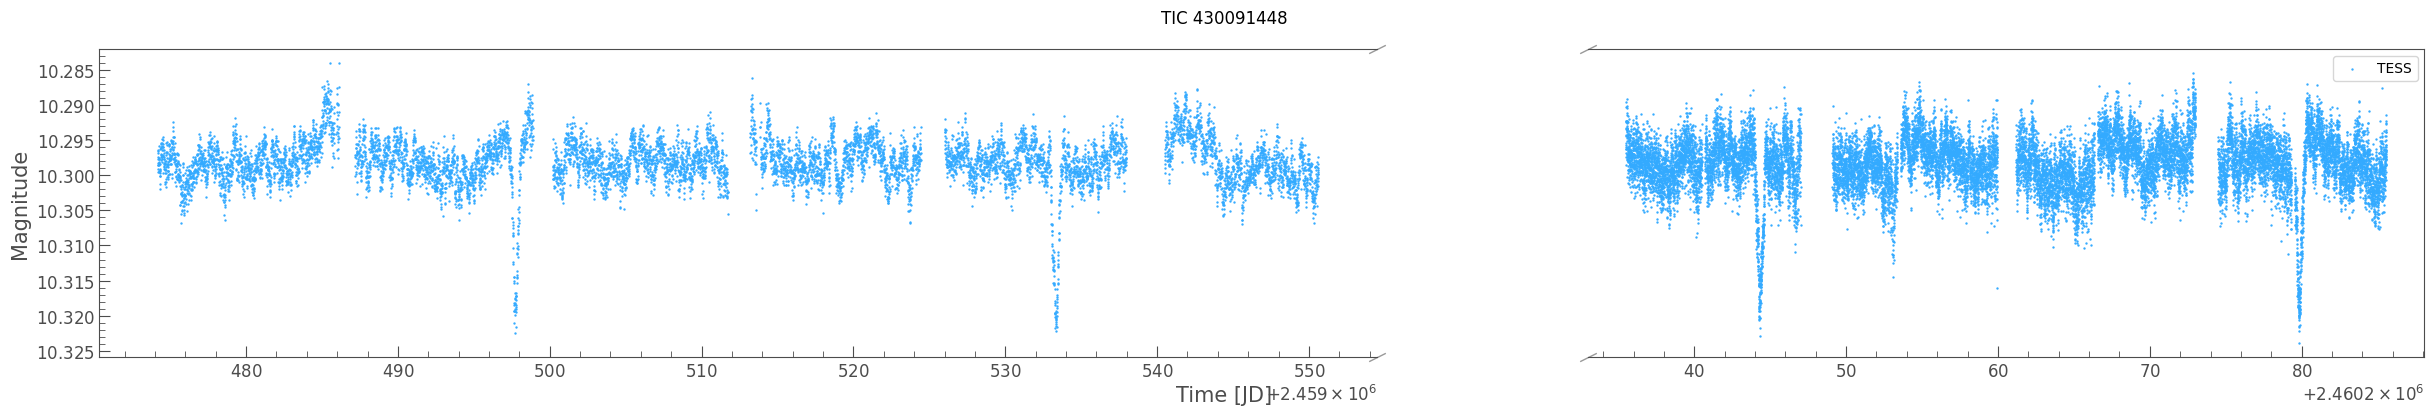

In [2]:
# # to shwo the eclipses and the time without eclipses
axs = tplt.plot_skip_data_gap(lc_combined_dict["TESS"], figsize=(30, 4), s=2, c="#3AF", label=lkem.get_label_of_source(lc_combined_dict, "TESS", mag_shift_precision=2));
axs[0].get_figure().suptitle(f"{primary_name}");

## VSX Report Table

In [71]:
def report_to_df(report):
    df = pd.DataFrame()
    df["Field"] = report.keys()
    df["Value"] = report.values()
    return df


def vsx_phase(phase):
    # the phase I used above is from [-0.5, +0.5]
    # convert to the phase [0, 1[ used by VSX
    if phase < -0.5 or phase > 0.5:
        raise ValueError(f"Input phase needs to be in [-0.5, 0.5] range. Actual: {phase}")
    if phase >= 0:
        return phase 
    else: 
        return 1 + phase


In [8]:
import bibs_utils
# reload(bibs_utils)

other_names = "UCAC4 550-027002,2MASS J06250190+1950545" # in ExoFOP and SIMBAD
other_names += ",LS V +19 5"  # SIMBAD primary name
# GSC: not adopted as its entry is a blend of the target and the neary star  --  https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-ref=VIZ6a17a08cc9ea1&-to=-4b&-from=-3&-this=-4&%2F%2Fsource=I%2F255&%2F%2Fc=96.25791++19.84847&%2F%2Ftables=I%2F255%2Fout&-out.max=50&%2F%2FCDSportal=http%3A%2F%2Fcdsportal.u-strasbg.fr%2FStoreVizierData.html&-out.form=HTML+Table&-out.add=_r&-out.add=_p&%2F%2Foutaddvalue=default&-order=I&-oc.form=sexa&-nav=cat%3AI%2F255%26tab%3A%7BI%2F255%2Fout%7D%26key%3Asource%3DI%2F255%26key%3Ac%3D96.25791++19.84847%26pos%3A96.25791++19.84847%28%29%26HTTPPRM%3A&-c=96.25791++19.84847&-c.eq=J2000&-c.r=+15&-c.u=arcsec&-c.geom=r&-source=&-out.src=I%2F255%2Fout&-source=I%2F255%2Fout&-out=GSC&-out=RAJ2000&-out=DEJ2000&-out=PosErr&-out=Pmag&-out=e_Pmag&-out=n_Pmag&-out=Class&-out=Epoch&-meta.ucd=2&-meta=1&-meta.foot=1&-meta.form=1&-usenav=1&-bmark=GET



remarks = (
    f"""Period might be twice the given value."""
    f""" Optical companion Gaia DR3 3372479140539725440, 9.86 V, 8.6" to the W."""  
    f""" Additional variation of amplitude 0.02 TESS. The source of the variation is uncertain."""
# the mag used is from Gaia DR3 for a) consistency, b) the 9.59 V in SIMBAD (from UCAC-4) is in-turn from APASS, which is a blend
# UCAC entries for the target and the compaion (8.574" away)
# - https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-ref=VIZ6a17a33c11175d&-to=-4b&-from=-3&-this=-4&%2F%2Fsource=I%2F322A&%2F%2Fc=96.25791++19.84847&%2F%2Ftables=I%2F322A%2Fout&-out.max=50&%2F%2FCDSportal=http%3A%2F%2Fcdsportal.u-strasbg.fr%2FStoreVizierData.html&-out.form=HTML+Table&-out.add=_r&-out.add=_p&%2F%2Foutaddvalue=default&-sort=_r&-order=I&-oc.form=sexa&-out.src=I%2F322A%2Fout&-nav=cat%3AI%2F322A%26tab%3A%7BI%2F322A%2Fout%7D%26key%3Asource%3DI%2F322A%26key%3Ac%3D96.25791++19.84847%26pos%3A96.25791++19.84847%28%29%26HTTPPRM%3A&-c=96.25791++19.84847&-c.eq=J2000&-c.r=+15&-c.u=arcsec&-c.geom=r&-source=&-source=I%2F322A%2Fout&-out=UCAC4&-out=RAJ2000&-out=DEJ2000&-out=ePos&-out=f.mag&-out=of&-out=db&-out=pmRA&-out=pmDE&-out=Jmag&-out=Kmag&-out=Bmag&-out=Vmag&-out=rmag&-out=imag&-out=H&-out=A&-out=b&-out=h&-out=Z&-out=B&-out=L&-out=N&-out=S&-meta.ucd=2&-meta=1&-meta.foot=1&-usenav=1&-bmark=GET
# APASS entry:
# - https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-source=II/336/apass9&-out.max=50&-out.form=HTML%20Table&-out.add=_r&-out.add=_RAJ,_DEJ&-sort=_r&-oc.form=sexa&-c=96.25791%20%2019.84847&-c.eq=J2000&-c.r=15&-c.u=arcsec&-c.geom=r&-sort=_r&-order=I&-out.add=_r&-out.add=_p&-out.add=_RAJ%2C_DEJ&%2F%2Foutaddvalue=default
)

# Not neeed for initial submission:
# - Type, period, epoch, eclipse duration from TESS data. Amplitude from TESS data.
revision_comment = "Maximum magnitude derived from Gaia DR3. Spectral type from 2016ApJS..224....4M. Gaia DR3 position."

# Reference note:
# also listed in TESS Ten Thousand Catalog: Eclipsing Binaries (Kostov+, 2025), but only as an unvalidated and unvetted entry (with no epoch, period, etc.)
# so it's ignored.
# https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-ref=VIZ6a176a2726cbb0&-to=4&-from=-3&-this=-4&%2F%2Fsource=J%2FApJS%2F279%2F50&%2F%2Fc=96.25791++19.84847&%2F%2Ftables=J%2FApJS%2F279%2F50%2Ftable3&%2F%2Ftables=J%2FApJS%2F279%2F50%2Ftable4&%2F%2Ftables=J%2FApJS%2F279%2F50%2Ftable2&-out.max=50&%2F%2FCDSportal=http%3A%2F%2Fcdsportal.u-strasbg.fr%2FStoreVizierData.html&-out.form=HTML+Table&-out.add=_r&-out.add=_p&%2F%2Foutaddvalue=default&-sort=_r&-order=I&-oc.form=sexa&-nav=cat%3AJ%2FApJS%2F279%2F50%26tab%3A%7BJ%2FApJS%2F279%2F50%2Ftable3%7D%26tab%3A%7BJ%2FApJS%2F279%2F50%2Ftable4%7D%26tab%3A%7BJ%2FApJS%2F279%2F50%2Ftable2%7D%26key%3Asource%3DJ%2FApJS%2F279%2F50%26key%3Ac%3D96.25791++19.84847%26pos%3A96.25791++19.84847%28+arcsec+J2000%29%26HTTPPRM%3A%26-ref%3DVIZ6a176a2726cbb0%26-out.max%3D50%26-out.form%3DHTML+Table%26-out.add%3D_r%26-out.add%3D_p%26-sort%3D_r%26-order%3DI%26-oc.form%3Dsexa%26-c%3D96.25791++19.84847%26-c.eq%3DJ2000%26-c.r%3D++15%26-c.u%3Darcsec%26-c.geom%3Dr%26-out.src%3DJ%2FApJS%2F279%2F50%2Ftable3%2CJ%2FApJS%2F279%2F50%2Ftable4%2CJ%2FApJS%2F279%2F50%2Ftable2%26-x.rs%3D10%26-out%3DTIC%26-out%3DRAJ2000%26-out%3DDEJ2000%26-out%3DTmag%26-out%3DPer%26-out%3DT0-pri%26-out%3DDepth-pri%26-out%3DDur-pri%26-out%3DT0-sec%26-out%3DPhase%26-out%3DDepth-sec%26-out%3DDur-sec%26-out%3DSect%26-out%3DRUWE%26-out%3DAEN%26-out%3DAENS%26-out%3DTeff%26-out%3DComm%26-out%3DSimbad%26-out%3DPer-TESS%26-out%3DT0-TESS%26-out%3DPer-Gaia%26-out%3DRatio1%26-out%3DPer-ASAS%26-out%3DRatio2%26-out%3DPer-ATLAS%26-out%3DRatio3%26-out%3DPer-VSX%26-out%3DRatio4%26-out%3DPer-WISE%26-out%3DRatio5%26-out%3DPer-ZTF%26-out%3DRatio6%26-meta.ucd%3D2%26-meta%3D1%26-meta.foot%3D1%26-usenav%3D1%26-bmark%3DGET%26-meta.form%3D1%26&-c=96.25791++19.84847&-c.eq=J2000&-c.r=+5&-c.u=arcsec&-c.geom=r&-source=&-out.src=J%2FApJS%2F279%2F50%2Ftable3%2CJ%2FApJS%2F279%2F50%2Ftable4%2CJ%2FApJS%2F279%2F50%2Ftable2&-x.rs=10&-source=J%2FApJS%2F279%2F50%2Ftable3+J%2FApJS%2F279%2F50%2Ftable4+J%2FApJS%2F279%2F50%2Ftable2&-out=TIC&-out=RAJ2000&-out=DEJ2000&-out=Tmag&-out=Per&-out=T0-pri&-out=Depth-pri&-out=Dur-pri&-out=T0-sec&-out=Phase&-out=Depth-sec&-out=Dur-sec&-out=Sect&-out=RUWE&-out=AEN&-out=AENS&-out=Teff&-out=Comm&-out=Simbad&-out=Per-TESS&-out=T0-TESS&-out=Per-Gaia&-out=Ratio1&-out=Per-ASAS&-out=Ratio2&-out=Per-ATLAS&-out=Ratio3&-out=Per-VSX&-out=Ratio4&-out=Per-WISE&-out=Ratio5&-out=Per-ZTF&-out=Ratio6&-meta.ucd=2&-meta=1&-meta.foot=1&-meta.form=1&-usenav=1&-bmark=GET

BIBS = bibs_utils.BIBS
vsx_report = dict(
    Position=f"{target_coord.ra.value:.5f}, {target_coord.dec.value:.5f}",  # VSX coordinate precision
    Primary_Name=primary_name,
    Other_Names=other_names,
    Variable_Type="EA",
    Spectral_Type="O9.5V",  # 2016ApJS..224....4M , in SIMBAD and B/mk
    Spectral_Type_Uncertain=False,
    Maximum_Magnitude=f"{median_flux_vmag}",  # from Gaia DR3
    Maximum_Magnitude_band="V",
    Minimum_Magnitude=f"{amp_min_i_flux_mag}",
    Minimum_Magnitude_band="TESS",  
    Minimum_Is_Amplitude=True,
    Period=f"{period_final}",  
    Period_Uncertain=False,
    Epoch=f"{epoch_time_hjd_final}",  
    Rise_Duration_Pct=f"{100 * duration_hr_min_i_final / 24 / float(period_final):.1f}",  # 1 decimal point is enough visually
    Discoverer="Sam Lee, Planet Hunters TESS Collaboration",  # PHT CTC Talk: zooniverse.org/projects/sofia-dot-marie/classifying-the-classified-2025/talk/7167/3813268?comment=6299194&page=1i
    Remarks=remarks,
    Revision_Comment=revision_comment,
    Reference0_Name=BIBS.QLP_N,
    Reference0_Bib=BIBS.QLP_B,
    Reference1_Name="Maíz Apellániz, J.; et al., 2016, The Galactic O-Star Spectroscopic Survey (GOSSS). III. 142 Additional O-type Systems.",
    Reference1_Bib="2016ApJS..224....4M",
)


def print_long_fields(report):
    other_names_list = report["Other_Names"].split(",")
    print("Other Names (1 line each):")
    print("\n".join(other_names_list))
    print("")
    print(report["Remarks"])
    print("")
    print(report["Revision_Comment"])

print_long_fields(vsx_report)
with pd.option_context('display.max_colwidth', None):
    display(report_to_df(vsx_report))


print("""
tic430091448_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS QLP data, outliers and systematics removed.
tic430091448_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS data. Zoomed around Min I.
tictic430091448_jd_plot_tess.png : TESS Lightcurve - Lightcurve from TESS QLP data, outliers and systematics removed.
""")


Other Names (1 line each):
UCAC4 550-027002
2MASS J06250190+1950545
LS V +19 5

Period might be twice the given value. Optical companion Gaia DR3 3372479140539725440, 9.86 V, 8.6" to the W. Additional variation of amplitude 0.02 TESS. The source of the variation is uncertain.

Maximum magnitude derived from Gaia DR3. Spectral type from 2016ApJS..224....4M. Gaia DR3 position.


,Field,Value
0,Position,"96.25791, 19.84847"
1,Primary_Name,TIC 430091448
2,Other_Names,"UCAC4 550-027002,2MASS J06250190+1950545,LS V +19 5"
3,Variable_Type,EA
4,Spectral_Type,O9.5V
5,Spectral_Type_Uncertain,False
6,Maximum_Magnitude,10.50
7,Maximum_Magnitude_band,V
8,Minimum_Magnitude,0.023
9,Minimum_Magnitude_band,TESS



tic430091448_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS QLP data, outliers and systematics removed.
tic430091448_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS data. Zoomed around Min I.
tictic430091448_jd_plot_tess.png : TESS Lightcurve - Lightcurve from TESS QLP data, outliers and systematics removed.

